**1 —  Environment Setup**

In [1]:
"""

Validates: src.features imported cleanly, all paths resolvable, 
MediaPipe/OpenCV available, feature constants correct.
"""

import sys
import warnings
from pathlib import Path

# ── Resolve repository root ──────────────────────────────────────────────────
# Handles both 'notebooks/' working directory and repo-root working directory.
_cwd = Path.cwd()
REPO_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Standard library ─────────────────────────────────────────────────────────
import json
import time
from collections import defaultdict
from datetime import datetime

# ── Numeric / data ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns

try:
    import cv2
    _CV2_OK = True
except ImportError:
    _CV2_OK = False
    print("⚠  opencv-python not importable — skeleton overlay will use dot-only fallback")

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Project utilities ─────────────────────────────────────────────────────────
from src.utils.logger import get_logger, configure_logging

from src.features.constants import (
    FEATURE_SIZE,
    N_HAND_LANDMARKS, N_POSE_LANDMARKS, N_COORDS_PER_LANDMARK,
    N_HAND_FEATURES,  N_POSE_FEATURES,
    LEFT_HAND_SLICE,  RIGHT_HAND_SLICE, POSE_SLICE,
    WRIST_LANDMARK_INDEX, EXTRACTOR_SCHEMA_VERSION,
)
from src.features.extractor import LandmarkExtractor

# Configure logger at WARNING so it doesn't clutter notebook output.
# File handler still captures DEBUG from the extractor.
configure_logging(
    log_dir=str(REPO_ROOT / "logs"),
    run_name="nb02_landmark_inspection",
    level="WARNING",
    file_level="DEBUG",
)
_log = get_logger(__name__)

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":          120,
    "figure.facecolor":    "white",
    "axes.facecolor":      "#f8f9fa",
    "axes.edgecolor":      "#cccccc",
    "axes.grid":           True,
    "grid.alpha":          0.35,
    "grid.linestyle":      "--",
    "font.family":         "DejaVu Sans",
    "axes.titlesize":      12,
    "axes.labelsize":      10,
    "legend.fontsize":     9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "figure.titlesize":    13,
    "figure.titleweight":  "bold",
    "lines.linewidth":     1.5,
})

# Colour constants reused across all cells
BAND_COLORS = {
    "left_hand":  "#1976D2",   # Material Blue 700
    "right_hand": "#E64A19",   # Material Deep-Orange 700
    "pose":       "#388E3C",   # Material Green 700
}
SPLIT_COLORS = {"train": "#1976D2", "val": "#F57C00", "test": "#388E3C"}

# Ablation sequence lengths (Stage 5 Group 3)
SEQ_LENS        = [20, 30, 40, 60]
DEFAULT_SEQ_LEN = 30

# ── Sanity-check feature constants ────────────────────────────────────────────
assert FEATURE_SIZE == 225,                           f"Expected 225, got {FEATURE_SIZE}"
assert LEFT_HAND_SLICE  == slice(0,   63),            f"Left hand slice wrong"
assert RIGHT_HAND_SLICE == slice(63,  126),           f"Right hand slice wrong"
assert POSE_SLICE       == slice(126, 225),           f"Pose slice wrong"
assert N_HAND_LANDMARKS == 21                         
assert N_POSE_LANDMARKS == 33                         

print(f"✓  Repository root      : {REPO_ROOT}")
print(f"✓  Extractor schema     : v{EXTRACTOR_SCHEMA_VERSION}")
print(f"✓  Feature vector size  : {FEATURE_SIZE} values/frame")
print(f"     [{LEFT_HAND_SLICE.start}:{LEFT_HAND_SLICE.stop}]   Left hand  — "
      f"{N_HAND_LANDMARKS} landmarks × {N_COORDS_PER_LANDMARK} coords = {N_HAND_FEATURES}")
print(f"     [{RIGHT_HAND_SLICE.start}:{RIGHT_HAND_SLICE.stop}]  Right hand — "
      f"{N_HAND_LANDMARKS} landmarks × {N_COORDS_PER_LANDMARK} coords = {N_HAND_FEATURES}")
print(f"     [{POSE_SLICE.start}:{POSE_SLICE.stop}] Pose       — "
      f"{N_POSE_LANDMARKS} landmarks × {N_COORDS_PER_LANDMARK} coords = {N_POSE_FEATURES}")
print(f"✓  Seq-len ablation     : {SEQ_LENS}")
print(f"✓  Matplotlib backend   : {matplotlib.get_backend()}")

2026-06-03 06:39:28 | DEBUG    | tensorflow | Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
2026-06-03 06:39:31 | DEBUG    | h5py._conv | Creating converter from 7 to 5
2026-06-03 06:39:31 | DEBUG    | h5py._conv | Creating converter from 5 to 7
2026-06-03 06:39:31 | DEBUG    | h5py._conv | Creating converter from 7 to 5
2026-06-03 06:39:31 | DEBUG    | h5py._conv | Creating converter from 5 to 7


DEBUG:2026-06-03 06:39:37,816:jax._src.path:45: etils.epath was not found. Using pathlib for file I/O.


2026-06-03 06:39:37 | DEBUG    | jax._src.path | etils.epath was not found. Using pathlib for file I/O.
2026-06-03 06:39:46 | INFO     | root | stage=init | Logging configured
2026-06-03 06:39:46 | INFO     | root | Log file: D:\PROJECTS\WLASL-Gesture-Recognition-System\logs\20260603_063946_nb02_landmark_inspection.log
✓  Repository root      : d:\PROJECTS\WLASL-Gesture-Recognition-System
✓  Extractor schema     : v1.1
✓  Feature vector size  : 225 values/frame
     [0:63]   Left hand  — 21 landmarks × 3 coords = 63
     [63:126]  Right hand — 21 landmarks × 3 coords = 63
     [126:225] Pose       — 33 landmarks × 3 coords = 99
✓  Seq-len ablation     : [20, 30, 40, 60]
✓  Matplotlib backend   : module://matplotlib_inline.backend_inline


**2 —  Project Constants, Paths & Data Loading**

In [2]:
"""
Loads:
  • artifacts/label_map_v1.json          → sign names, properties, confusable pairs
  • data/splits/{train,val,test}.csv     → clip metadata with signer_id, video_path
  • data/landmarks/landmark_inventory.csv → Stage 3 per-clip extraction statistics
  • data/preprocessing_summary_latest.json → aggregate run metadata

Merges inventory with splits on video_id to attach signer_id and video_path.
Sets IS_SAMPLE flag for conditional messaging throughout the notebook.
"""

# ── Paths ────────────────────────────────────────────────────────────────────
SPLITS_DIR    = REPO_ROOT / "data" / "splits"
LANDMARKS_DIR = REPO_ROOT / "data" / "landmarks"
ARTIFACTS_DIR = REPO_ROOT / "artifacts"
REPORTS_DIR   = REPO_ROOT / "reports"
FIGURES_DIR   = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

LABEL_MAP_PATH = ARTIFACTS_DIR / "label_map_v1.json"
INVENTORY_CSV  = LANDMARKS_DIR / "landmark_inventory.csv"
SUMMARY_JSON   = REPO_ROOT / "data" / "preprocessing_summary_latest.json"

# ── Load label map ────────────────────────────────────────────────────────────
if not LABEL_MAP_PATH.exists():
    raise FileNotFoundError(f"Label map not found: {LABEL_MAP_PATH}")

with open(LABEL_MAP_PATH, encoding="utf-8") as _f:
    _lm_raw = json.load(_f)

# {class_idx: sign_name}
CLASSES     = {int(k): v for k, v in _lm_raw["classes"].items()}
# {sign_name: class_idx}
CLASSES_INV = {v: k for k, v in CLASSES.items()}
# Per-sign semantic properties from label_map_v1.json
SIGN_PROPS  = _lm_raw.get("sign_properties", {})
# Ordered list — ALL_SIGNS[i] == CLASSES[i]
ALL_SIGNS   = [CLASSES[i] for i in sorted(CLASSES)]
N_CLASSES   = len(CLASSES)

print(f"✓  Label map v{_lm_raw['_metadata']['format_version']} — "
      f"{N_CLASSES} classes  ({ALL_SIGNS[0]} … {ALL_SIGNS[-1]})")

# ── Load split CSVs ───────────────────────────────────────────────────────────
_split_frames = {}
for _split in ("train", "val", "test"):
    _p = SPLITS_DIR / f"{_split}.csv"
    if _p.exists():
        _split_frames[_split] = pd.read_csv(_p)
        print(f"  {_split:5s}: {len(_split_frames[_split])} clips, "
              f"{_split_frames[_split]['sign_label'].nunique()} signs, "
              f"{_split_frames[_split]['signer_id'].nunique()} signers")
    else:
        print(f"  ⚠  {_split}.csv not found — run Stage 1 first")

SPLITS_DF = (
    pd.concat(_split_frames.values(), ignore_index=True)
    if _split_frames else pd.DataFrame()
)

# ── Load landmark inventory ───────────────────────────────────────────────────
if not INVENTORY_CSV.exists():
    raise FileNotFoundError(
        f"landmark_inventory.csv not found at {INVENTORY_CSV}.\n"
        "Run Stage 3 extraction before this notebook:\n"
        "  python pipelines/run_landmark_extraction.py --sample-only"
    )

INV_DF = pd.read_csv(INVENTORY_CSV)

# Merge with splits to get signer_id, video_path, frame_count, duration_sec
_merge_cols = [c for c in ["video_id", "class_idx", "signer_id",
                             "video_path", "frame_count", "duration_sec"]
               if c in SPLITS_DF.columns]
INV_DF = INV_DF.merge(
    SPLITS_DF[_merge_cols].drop_duplicates("video_id"),
    on="video_id",
    how="left",
    suffixes=("", "_split"),
)

# Usable = freshly extracted or loaded from cache (not skipped or error)
INV_USABLE = INV_DF[INV_DF["outcome"].isin(["extracted", "cached"])].copy()
INV_USABLE = INV_USABLE.reset_index(drop=True)

# Heuristic: <200 usable clips almost certainly means sample-only run
IS_SAMPLE = len(INV_USABLE) < 200

print(f"\n✓  Landmark inventory   : {len(INV_DF)} total entries")
print(f"     Usable (extracted+cached) : {len(INV_USABLE)}")
print(f"     Skipped (policy)          : {(INV_DF['outcome'] == 'skipped').sum()}")
print(f"     Errors                    : {(INV_DF['outcome'] == 'error').sum()}")
print(f"     Signs with usable data    : {INV_USABLE['sign_label'].nunique()} / {N_CLASSES}")
print(f"\n  ▶  Mode: "
      f"{'⚠ SAMPLE — statistics limited to ≤3 clips/sign; re-run cells 7–14 after full extraction' if IS_SAMPLE else '✓ FULL DATASET'}")

✓  Label map v1.1 — 35 classes  (before … who)
  train: 245 clips, 35 signs, 31 signers
  val  : 53 clips, 35 signs, 7 signers
  test : 52 clips, 35 signs, 7 signers

✓  Landmark inventory   : 208 total entries
     Usable (extracted+cached) : 50
     Skipped (policy)          : 158
     Errors                    : 0
     Signs with usable data    : 30 / 35

  ▶  Mode: ⚠ SAMPLE — statistics limited to ≤3 clips/sign; re-run cells 7–14 after full extraction


**3 — Extraction Run Summary**

STAGE 3 EXTRACTION RUN SUMMARY
  Run ID            : 20260602T184706Z
  Extractor schema  : v1.1
  Status            : completed
  Max missing pct   : 30%  (skip threshold — applied over decoded frames only)

  Queued            :   208
  Extracted (fresh) :    35
  Cached            :    15
  Usable total      :    50
  Skipped (policy)  :   158  (76.0%)
  Errors            :     0  (0.0%)

  Total frames                :    1,799
  Decode failures  [v1.1]     :       70  (codec errors — NOT counted in missing_pct)
  Global missing rate [v1.1]  :   14.63%  (both-hands absent over decoded frames)
  Processing time             :   1533.2s


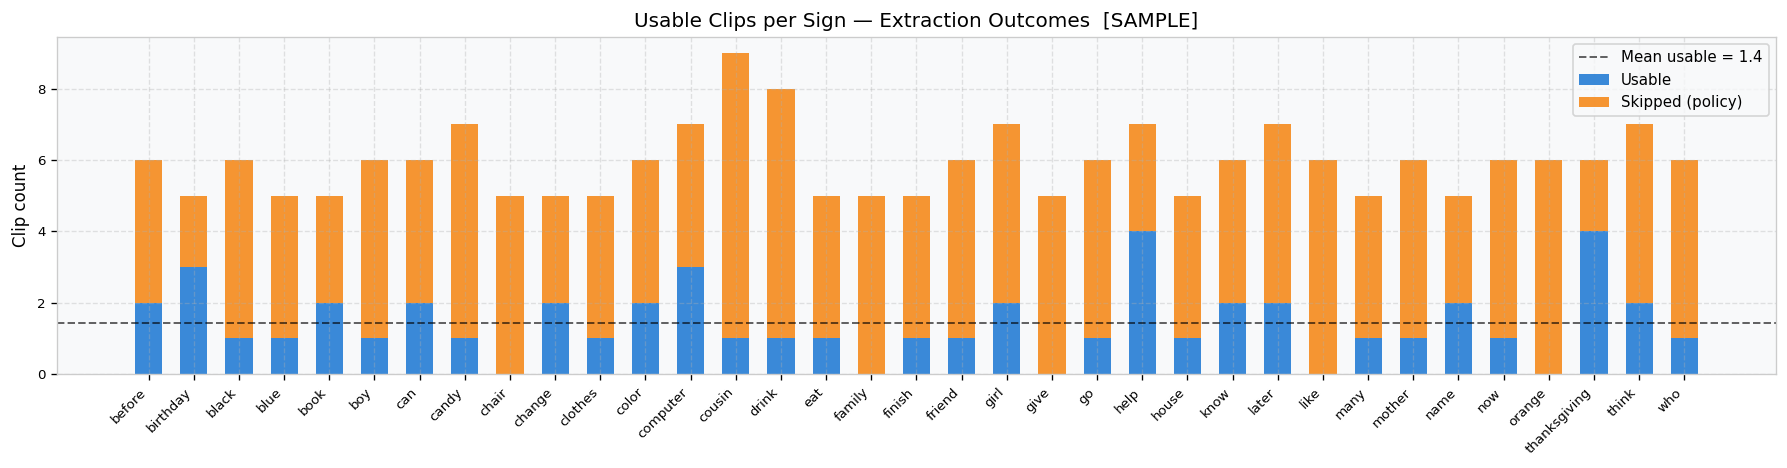

✓  Saved: nb02_extraction_outcomes.png
   Min usable: 0 (chair)  |  Max: 4 (help)


In [3]:
"""
Reads preprocessing_summary_latest.json (written by run_landmark_extraction.py)
and prints the structured aggregate statistics, then produces a compact bar chart
of per-sign extraction outcomes.

Key metrics surfaced:
  • Policy skip rate (expected 5–8% for WLASL with v1.1 extractor)
  • Global missing-landmark rate (over successfully-decoded frames — v1.1)
  • Decode failure rate (v1.1: codec errors, excluded from missing_pct denominator)
"""

# ── Load summary JSON ─────────────────────────────────────────────────────────
_summary = {}
if SUMMARY_JSON.exists():
    with open(SUMMARY_JSON, encoding="utf-8") as _f:
        _summary = json.load(_f)
else:
    print("⚠  preprocessing_summary_latest.json not found — aggregate stats unavailable")

_meta = _summary.get("_run_metadata", {})
_agg  = _summary.get("aggregate",     {})

if _meta or _agg:
    print("=" * 62)
    print("STAGE 3 EXTRACTION RUN SUMMARY")
    print("=" * 62)
    print(f"  Run ID            : {_meta.get('run_id', 'N/A')}")
    print(f"  Extractor schema  : v{_meta.get('extractor_schema', 'N/A')}")
    print(f"  Status            : {_meta.get('status', 'N/A')}")
    print(f"  Max missing pct   : {_meta.get('max_missing_frame_pct', 0.3):.0%}  "
          "(skip threshold — applied over decoded frames only)")
    print()
    print(f"  Queued            : {_agg.get('n_queued',          0):>5}")
    print(f"  Extracted (fresh) : {_agg.get('n_extracted',       0):>5}")
    print(f"  Cached            : {_agg.get('n_cached',          0):>5}")
    print(f"  Usable total      : {_agg.get('n_usable',          0):>5}")
    print(f"  Skipped (policy)  : {_agg.get('n_skipped_policy',  0):>5}  "
          f"({_agg.get('policy_skip_rate', 0):.1%})")
    print(f"  Errors            : {_agg.get('n_skipped_error',   0):>5}  "
          f"({_agg.get('error_rate', 0):.1%})")
    print()
    print(f"  Total frames                : {_agg.get('total_frames',          0):>8,}")
    print(f"  Decode failures  [v1.1]     : {_agg.get('total_decode_failures', 0):>8,}  "
          "(codec errors — NOT counted in missing_pct)")
    print(f"  Global missing rate [v1.1]  : {_agg.get('global_missing_rate',  0):>8.2%}  "
          "(both-hands absent over decoded frames)")
    print(f"  Processing time             : {_agg.get('total_proc_sec',        0):>8.1f}s")
    print("=" * 62)

# ── Per-sign outcome pivot ────────────────────────────────────────────────────
_outcome_pivot = (
    INV_DF.groupby(["sign_label", "outcome"])
    .size()
    .unstack(fill_value=0)
)
for _col in ["extracted", "cached", "skipped", "error"]:
    if _col not in _outcome_pivot.columns:
        _outcome_pivot[_col] = 0

_outcome_pivot["usable"]    = _outcome_pivot["extracted"] + _outcome_pivot["cached"]
_outcome_pivot["class_idx"] = _outcome_pivot.index.map(CLASSES_INV)
_outcome_pivot              = _outcome_pivot.sort_values("class_idx")
_sorted_signs               = _outcome_pivot.index.tolist()

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 4))
_x = np.arange(len(_sorted_signs))
_w = 0.6

ax.bar(_x, _outcome_pivot["usable"],  _w, color="#1976D2", alpha=0.85, label="Usable")
if _outcome_pivot["skipped"].sum() > 0:
    ax.bar(_x, _outcome_pivot["skipped"], _w,
           bottom=_outcome_pivot["usable"],
           color="#F57C00", alpha=0.8, label="Skipped (policy)")
if _outcome_pivot["error"].sum() > 0:
    ax.bar(_x, _outcome_pivot["error"], _w,
           bottom=_outcome_pivot["usable"] + _outcome_pivot["skipped"],
           color="#C62828", alpha=0.8, label="Error")

_mean_usable = _outcome_pivot["usable"].mean()
ax.axhline(_mean_usable, color="black", linestyle="--", linewidth=1.2, alpha=0.6,
           label=f"Mean usable = {_mean_usable:.1f}")

ax.set_xticks(_x)
ax.set_xticklabels(_sorted_signs, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Clip count")
ax.set_title(
    f"Usable Clips per Sign — Extraction Outcomes  "
    f"[{'SAMPLE' if IS_SAMPLE else 'FULL DATASET'}]",
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb02_extraction_outcomes.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓  Saved: nb02_extraction_outcomes.png")
print(f"   Min usable: {_outcome_pivot['usable'].min()} ({_outcome_pivot['usable'].idxmin()})  |  "
      f"Max: {_outcome_pivot['usable'].max()} ({_outcome_pivot['usable'].idxmax()})")

**4 — Sample Coverage Map**

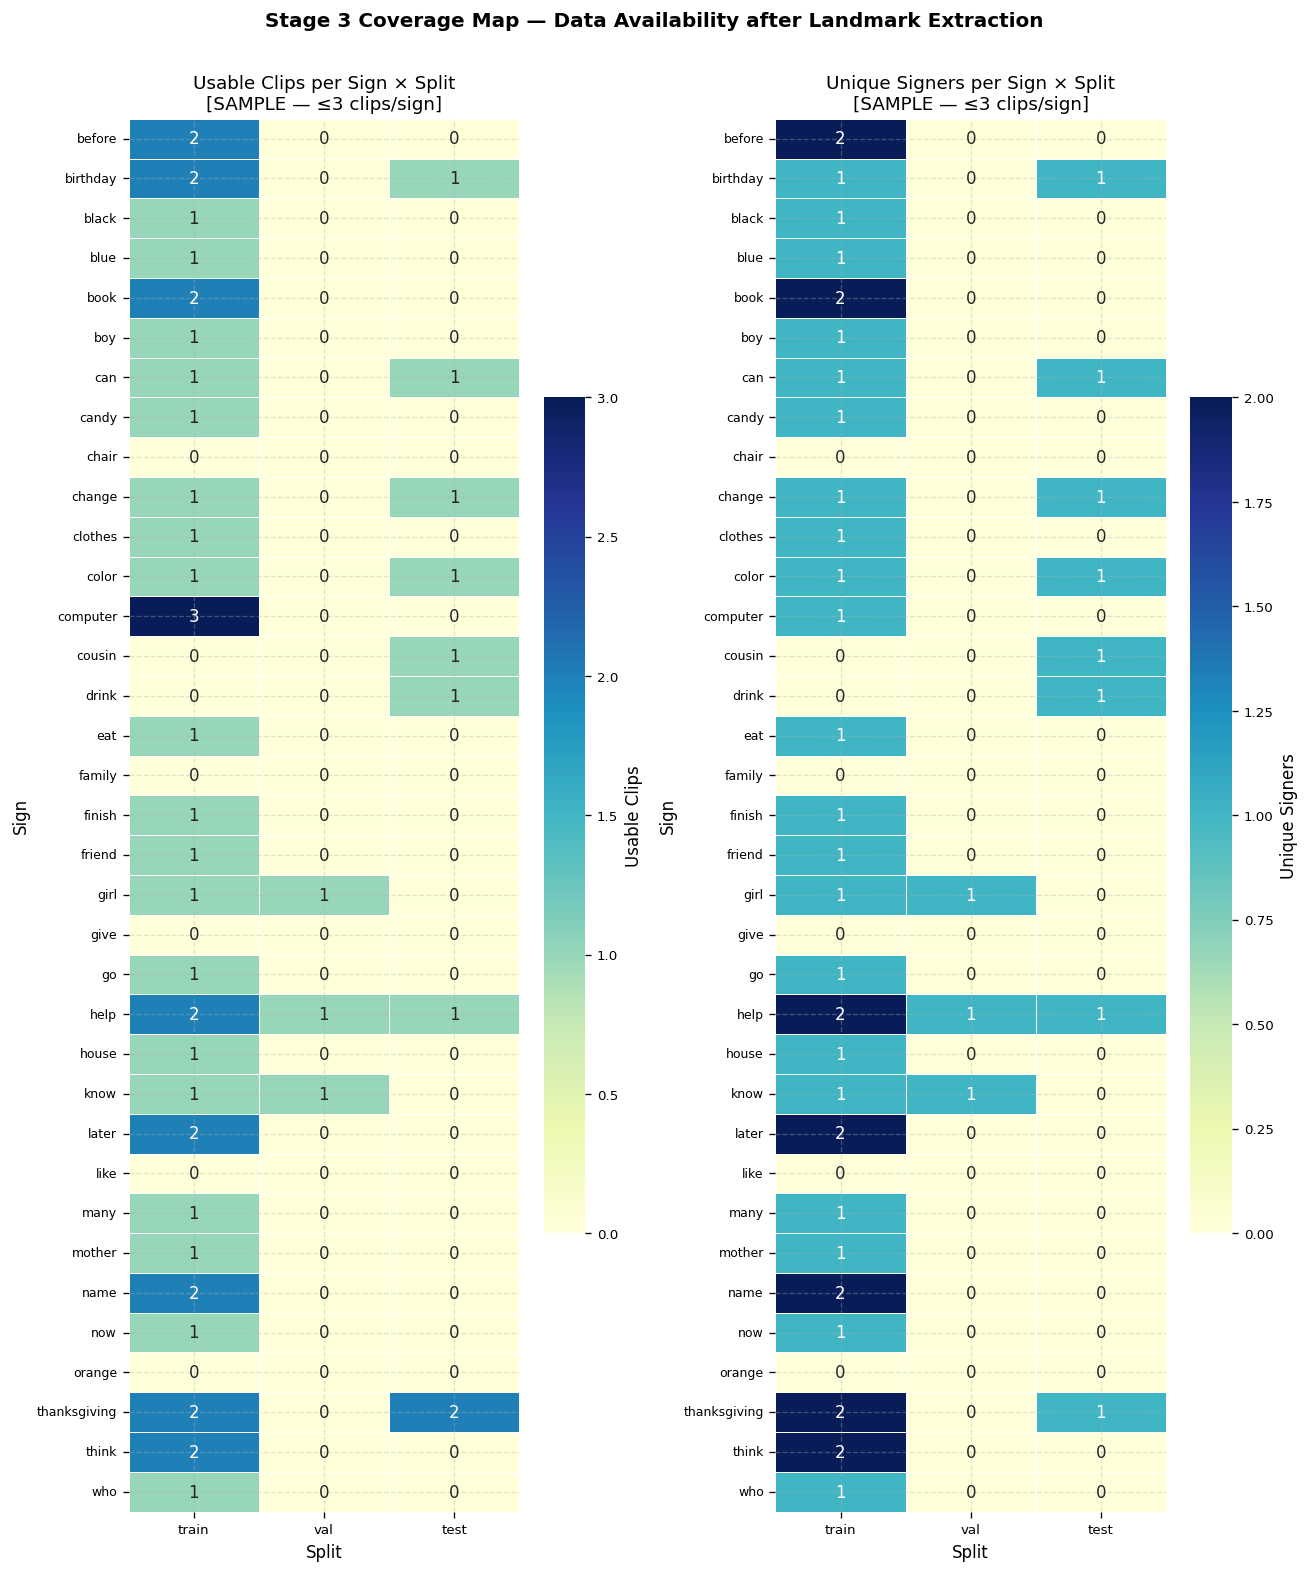

✓  Saved: nb02_coverage_map.png

Coverage diagnostics:
  Signs with ≥1 clip in ALL splits  : 1 / 35
  ⚠  Signs with 0 train clips       : ['chair', 'cousin', 'drink', 'family', 'give', 'like', 'orange']
  ⚠  Signs with exactly 1 val clip  : ['girl', 'help', 'know']
     → Per-class val metrics unreliable for these signs (Stage 6 limitation)


In [4]:
"""
Shows how many usable clips are available for each sign in each split.
Critical diagnostic: signs with 0 usable clips in any split cannot contribute
to signer-aware evaluation for that split.
"""

# ── Pivot: sign × split ───────────────────────────────────────────────────────
_coverage_pivot = (
    INV_USABLE.groupby(["sign_label", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(ALL_SIGNS, fill_value=0)
)
_coverage_pivot = _coverage_pivot.reindex(
    columns=[c for c in ["train", "val", "test"] if c in _coverage_pivot.columns]
)

# Signer counts per sign per split
_signer_pivot = (
    INV_USABLE[INV_USABLE["signer_id"].notna()]
    .groupby(["sign_label", "split"])["signer_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(ALL_SIGNS, fill_value=0)
)
_signer_pivot = _signer_pivot.reindex(
    columns=[c for c in ["train", "val", "test"] if c in _signer_pivot.columns]
)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 13))

for ax, data, title, fmt in [
    (axes[0], _coverage_pivot, "Usable Clips",     "d"),
    (axes[1], _signer_pivot,   "Unique Signers",   "d"),
]:
    sns.heatmap(
        data,
        ax=ax,
        annot=True,
        fmt=fmt,
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": title, "shrink": 0.6},
        vmin=0,
    )
    ax.set_title(f"{title} per Sign × Split\n"
                 f"{'[SAMPLE — ≤3 clips/sign]' if IS_SAMPLE else '[FULL DATASET]'}",
                 fontsize=11)
    ax.set_xlabel("Split")
    ax.set_ylabel("Sign")
    ax.tick_params(axis="y", labelsize=7.5)

plt.suptitle("Stage 3 Coverage Map — Data Availability after Landmark Extraction",
             fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb02_coverage_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb02_coverage_map.png")

# ── Diagnostics ───────────────────────────────────────────────────────────────
_n_all_splits = ((_coverage_pivot > 0).all(axis=1)).sum()
print(f"\nCoverage diagnostics:")
print(f"  Signs with ≥1 clip in ALL splits  : {_n_all_splits} / {N_CLASSES}")

_zero_train = _coverage_pivot[_coverage_pivot.get("train", pd.Series(0, index=ALL_SIGNS)) == 0].index.tolist()
if _zero_train:
    print(f"  ⚠  Signs with 0 train clips       : {_zero_train}")
else:
    print(f"  ✓  All signs have ≥1 train clip")

# Signs with only 1 val clip (can't compute per-class val metrics reliably)
if "val" in _coverage_pivot.columns:
    _one_val = _coverage_pivot[_coverage_pivot["val"] == 1].index.tolist()
    if _one_val:
        print(f"  ⚠  Signs with exactly 1 val clip  : {_one_val}")
        print(f"     → Per-class val metrics unreliable for these signs (Stage 6 limitation)")

**5 — Landmark Skeleton Overlay**

2026-06-03 06:40:02 | INFO     | src.features.extractor | stage=extraction | LandmarkExtractor initialised | schema_version=1.1 | max_missing_pct=30% | model_complexity=1 | sample_clips_per_sign=3 | landmarks_dir=d:\PROJECTS\WLASL-Gesture-Recognition-System\data\landmarks


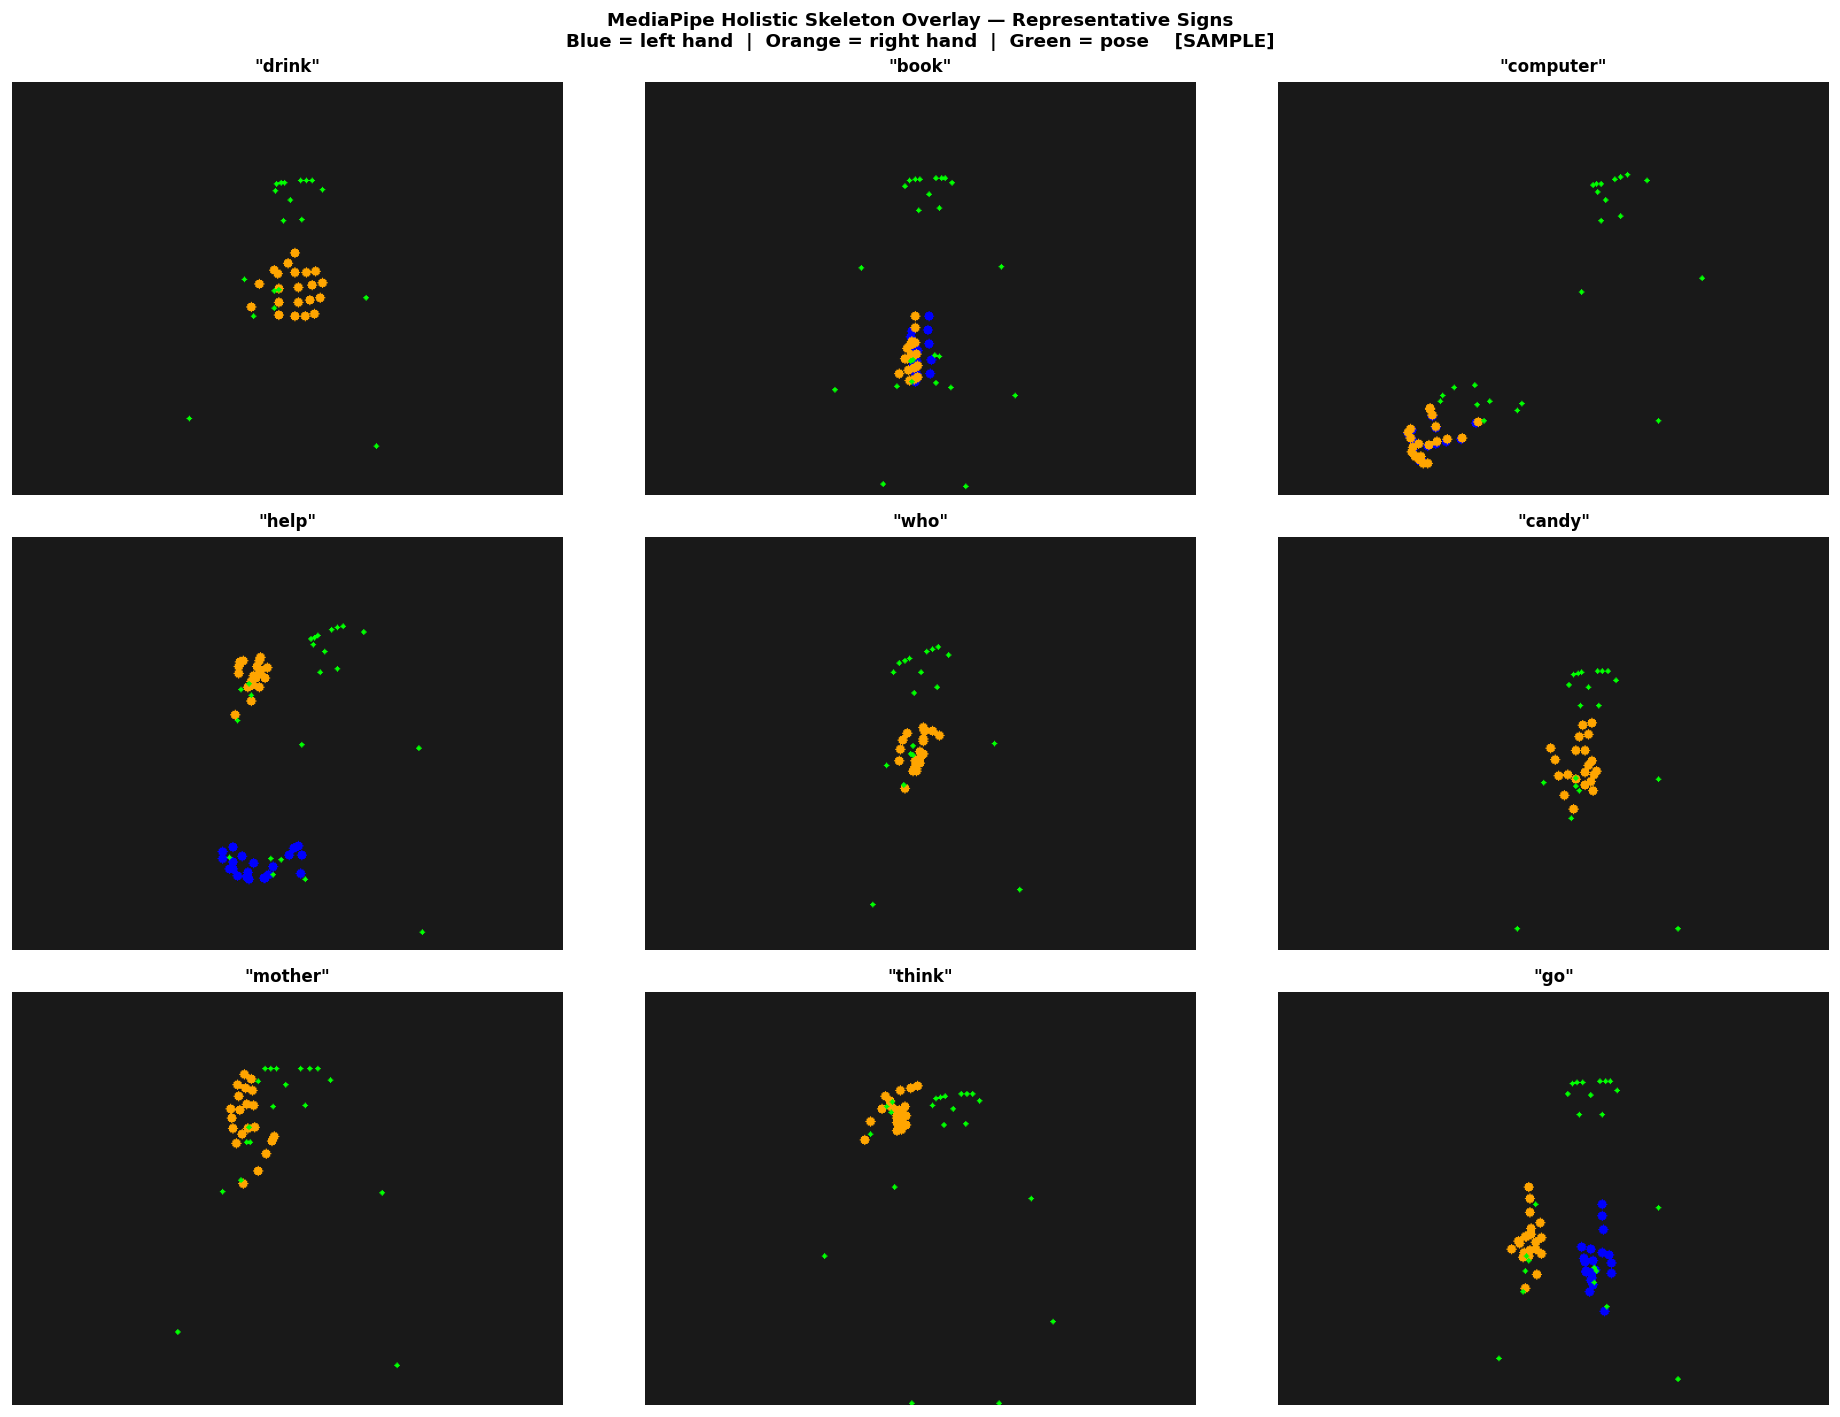

✓  Saved: nb02_skeleton_overlay.png
   Signs shown: ['drink', 'book', 'computer', 'help', 'who', 'candy', 'mother', 'think', 'go']


In [5]:
"""
For 9 representative signs, renders MediaPipe Holistic keypoints on the
video frame with highest landmark coverage (best frame in each clip).

Two rendering modes:
  1. Video available → overlay landmarks on actual video frame
  2. Video unavailable → draw landmarks as coloured dots on a dark canvas

Uses LandmarkExtractor.draw_landmarks(frame_bgr, feature_vec=arr[i]) which
handles both modes internally.
"""

# ── Helper functions ──────────────────────────────────────────────────────────
def load_npy(path_str: str) -> np.ndarray | None:
    """Load a (N, 225) float32 landmark array from disk. Returns None on failure."""
    if not path_str or str(path_str).lower() in ("nan", "none", ""):
        return None
    p = Path(path_str)
    if not p.is_absolute():
        p = REPO_ROOT / p
    if not p.exists():
        return None
    try:
        arr = np.load(str(p), allow_pickle=False)
        if arr.ndim != 2 or arr.shape[1] != FEATURE_SIZE:
            return None
        return arr.astype(np.float32)
    except Exception:
        return None


def best_frame_idx(arr: np.ndarray) -> int:
    """Return the frame with maximum non-zero landmark count."""
    # Count non-zero features per frame, prefer middle third of clip
    n = arr.shape[0]
    nonzero = (arr != 0).sum(axis=1).astype(float)
    # Slight boost to middle-third frames (avoids black first/last frames)
    mid_start, mid_end = n // 4, 3 * n // 4
    nonzero[mid_start:mid_end] *= 1.05
    return int(nonzero.argmax())


def load_video_frame(video_path_str: str, frame_idx: int) -> np.ndarray | None:
    """
    Load frame at frame_idx from a video file.
    Returns an RGB uint8 array, or None if unavailable.
    """
    if not _CV2_OK or not video_path_str or str(video_path_str).lower() in ("nan", "none", ""):
        return None
    vp = Path(video_path_str)
    if not vp.is_absolute():
        vp = REPO_ROOT / vp
    if not vp.exists():
        return None
    try:
        cap = cv2.VideoCapture(str(vp))
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        safe_idx = min(frame_idx, max(total - 1, 0))
        cap.set(cv2.CAP_PROP_POS_FRAMES, safe_idx)
        ret, frame = cap.read()
        cap.release()
        if ret and frame is not None and frame.size > 0:
            return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return None
    except Exception:
        return None


def blank_canvas(h: int = 360, w: int = 480) -> np.ndarray:
    """Dark canvas for when source video is unavailable."""
    return np.full((h, w, 3), 25, dtype=np.uint8)


def get_video_path_for_clip(video_id: str) -> str:
    """Look up video_path from the splits DataFrame."""
    row = SPLITS_DF[SPLITS_DF["video_id"] == video_id]
    if row.empty or "video_path" not in row.columns:
        return ""
    return str(row.iloc[0]["video_path"])


# ── Showcase sign selection ───────────────────────────────────────────────────
# Prefer variety across motion type and handedness.
_CANDIDATES = [
    "drink", "book", "computer", "help", "who",
    "candy", "mother", "think", "go",
    "before", "change", "give", "know",
]
_showcase_signs = []
for _s in _CANDIDATES:
    if (_s in INV_USABLE["sign_label"].values and
            len(INV_USABLE[INV_USABLE["sign_label"] == _s]) > 0):
        _showcase_signs.append(_s)
    if len(_showcase_signs) == 9:
        break

# Pad to 9 with remaining signs if needed
if len(_showcase_signs) < 9:
    for _s in ALL_SIGNS:
        if _s not in _showcase_signs and _s in INV_USABLE["sign_label"].values:
            _showcase_signs.append(_s)
        if len(_showcase_signs) == 9:
            break

# ── Initialise extractor (lazy — only loads MP model if not already warm) ─────
_extractor = LandmarkExtractor(landmarks_dir=str(LANDMARKS_DIR))

# ── Render grid ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "MediaPipe Holistic Skeleton Overlay — Representative Signs\n"
    f"Blue = left hand  |  Orange = right hand  |  Green = pose  "
    f"  {'[SAMPLE]' if IS_SAMPLE else '[FULL]'}",
    fontsize=11,
)

for _i, _sign in enumerate(_showcase_signs[:9]):
    ax = fig.add_subplot(3, 3, _i + 1)
    ax.set_title(f'"{_sign}"', fontsize=10, fontweight="bold")
    ax.axis("off")

    # Get best clip for this sign (lowest missing rate in train)
    _clips = INV_USABLE[INV_USABLE["sign_label"] == _sign]
    _train = _clips[_clips["split"] == "train"]
    _row   = (_train if not _train.empty else _clips).sort_values(
        "missing_both_pct"
    ).iloc[0]

    _arr = load_npy(_row.get("output_path", ""))
    if _arr is None or _arr.shape[0] == 0:
        ax.text(0.5, 0.5, "No .npy data", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="gray")
        continue

    _fi      = best_frame_idx(_arr)
    _feat    = _arr[_fi]                            # (225,)
    _vid_id  = str(_row.get("video_id", ""))
    _vid_path = get_video_path_for_clip(_vid_id)

    # Try real video frame first
    _frame_rgb = load_video_frame(_vid_path, _fi)
    _has_video = _frame_rgb is not None
    if not _has_video:
        _frame_rgb = blank_canvas()

    # draw_landmarks expects BGR
    _frame_bgr     = cv2.cvtColor(_frame_rgb, cv2.COLOR_RGB2BGR) if _CV2_OK else _frame_rgb
    _annotated_bgr = _extractor.draw_landmarks(_frame_bgr, feature_vec=_feat)
    _annotated_rgb = cv2.cvtColor(_annotated_bgr, cv2.COLOR_BGR2RGB) if _CV2_OK else _annotated_bgr

    ax.imshow(_annotated_rgb)

    # Subtitle with detection stats
    _pct_nonzero = float((_feat != 0).sum()) / FEATURE_SIZE
    _lh_ok = (_feat[LEFT_HAND_SLICE]  != 0).any()
    _rh_ok = (_feat[RIGHT_HAND_SLICE] != 0).any()
    _ps_ok = (_feat[POSE_SLICE]       != 0).any()
    _det_str = f"L={'✓' if _lh_ok else '✗'}  R={'✓' if _rh_ok else '✗'}  P={'✓' if _ps_ok else '✗'}"
    _src_str = "" if _has_video else "  [no video]"
    ax.set_xlabel(
        f"frame {_fi}/{_arr.shape[0]-1}  •  {_pct_nonzero:.0%} detected  •  {_det_str}{_src_str}",
        fontsize=7,
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb02_skeleton_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓  Saved: nb02_skeleton_overlay.png")
print(f"   Signs shown: {_showcase_signs[:9]}")

**6 — Feature Vector Heatmap**

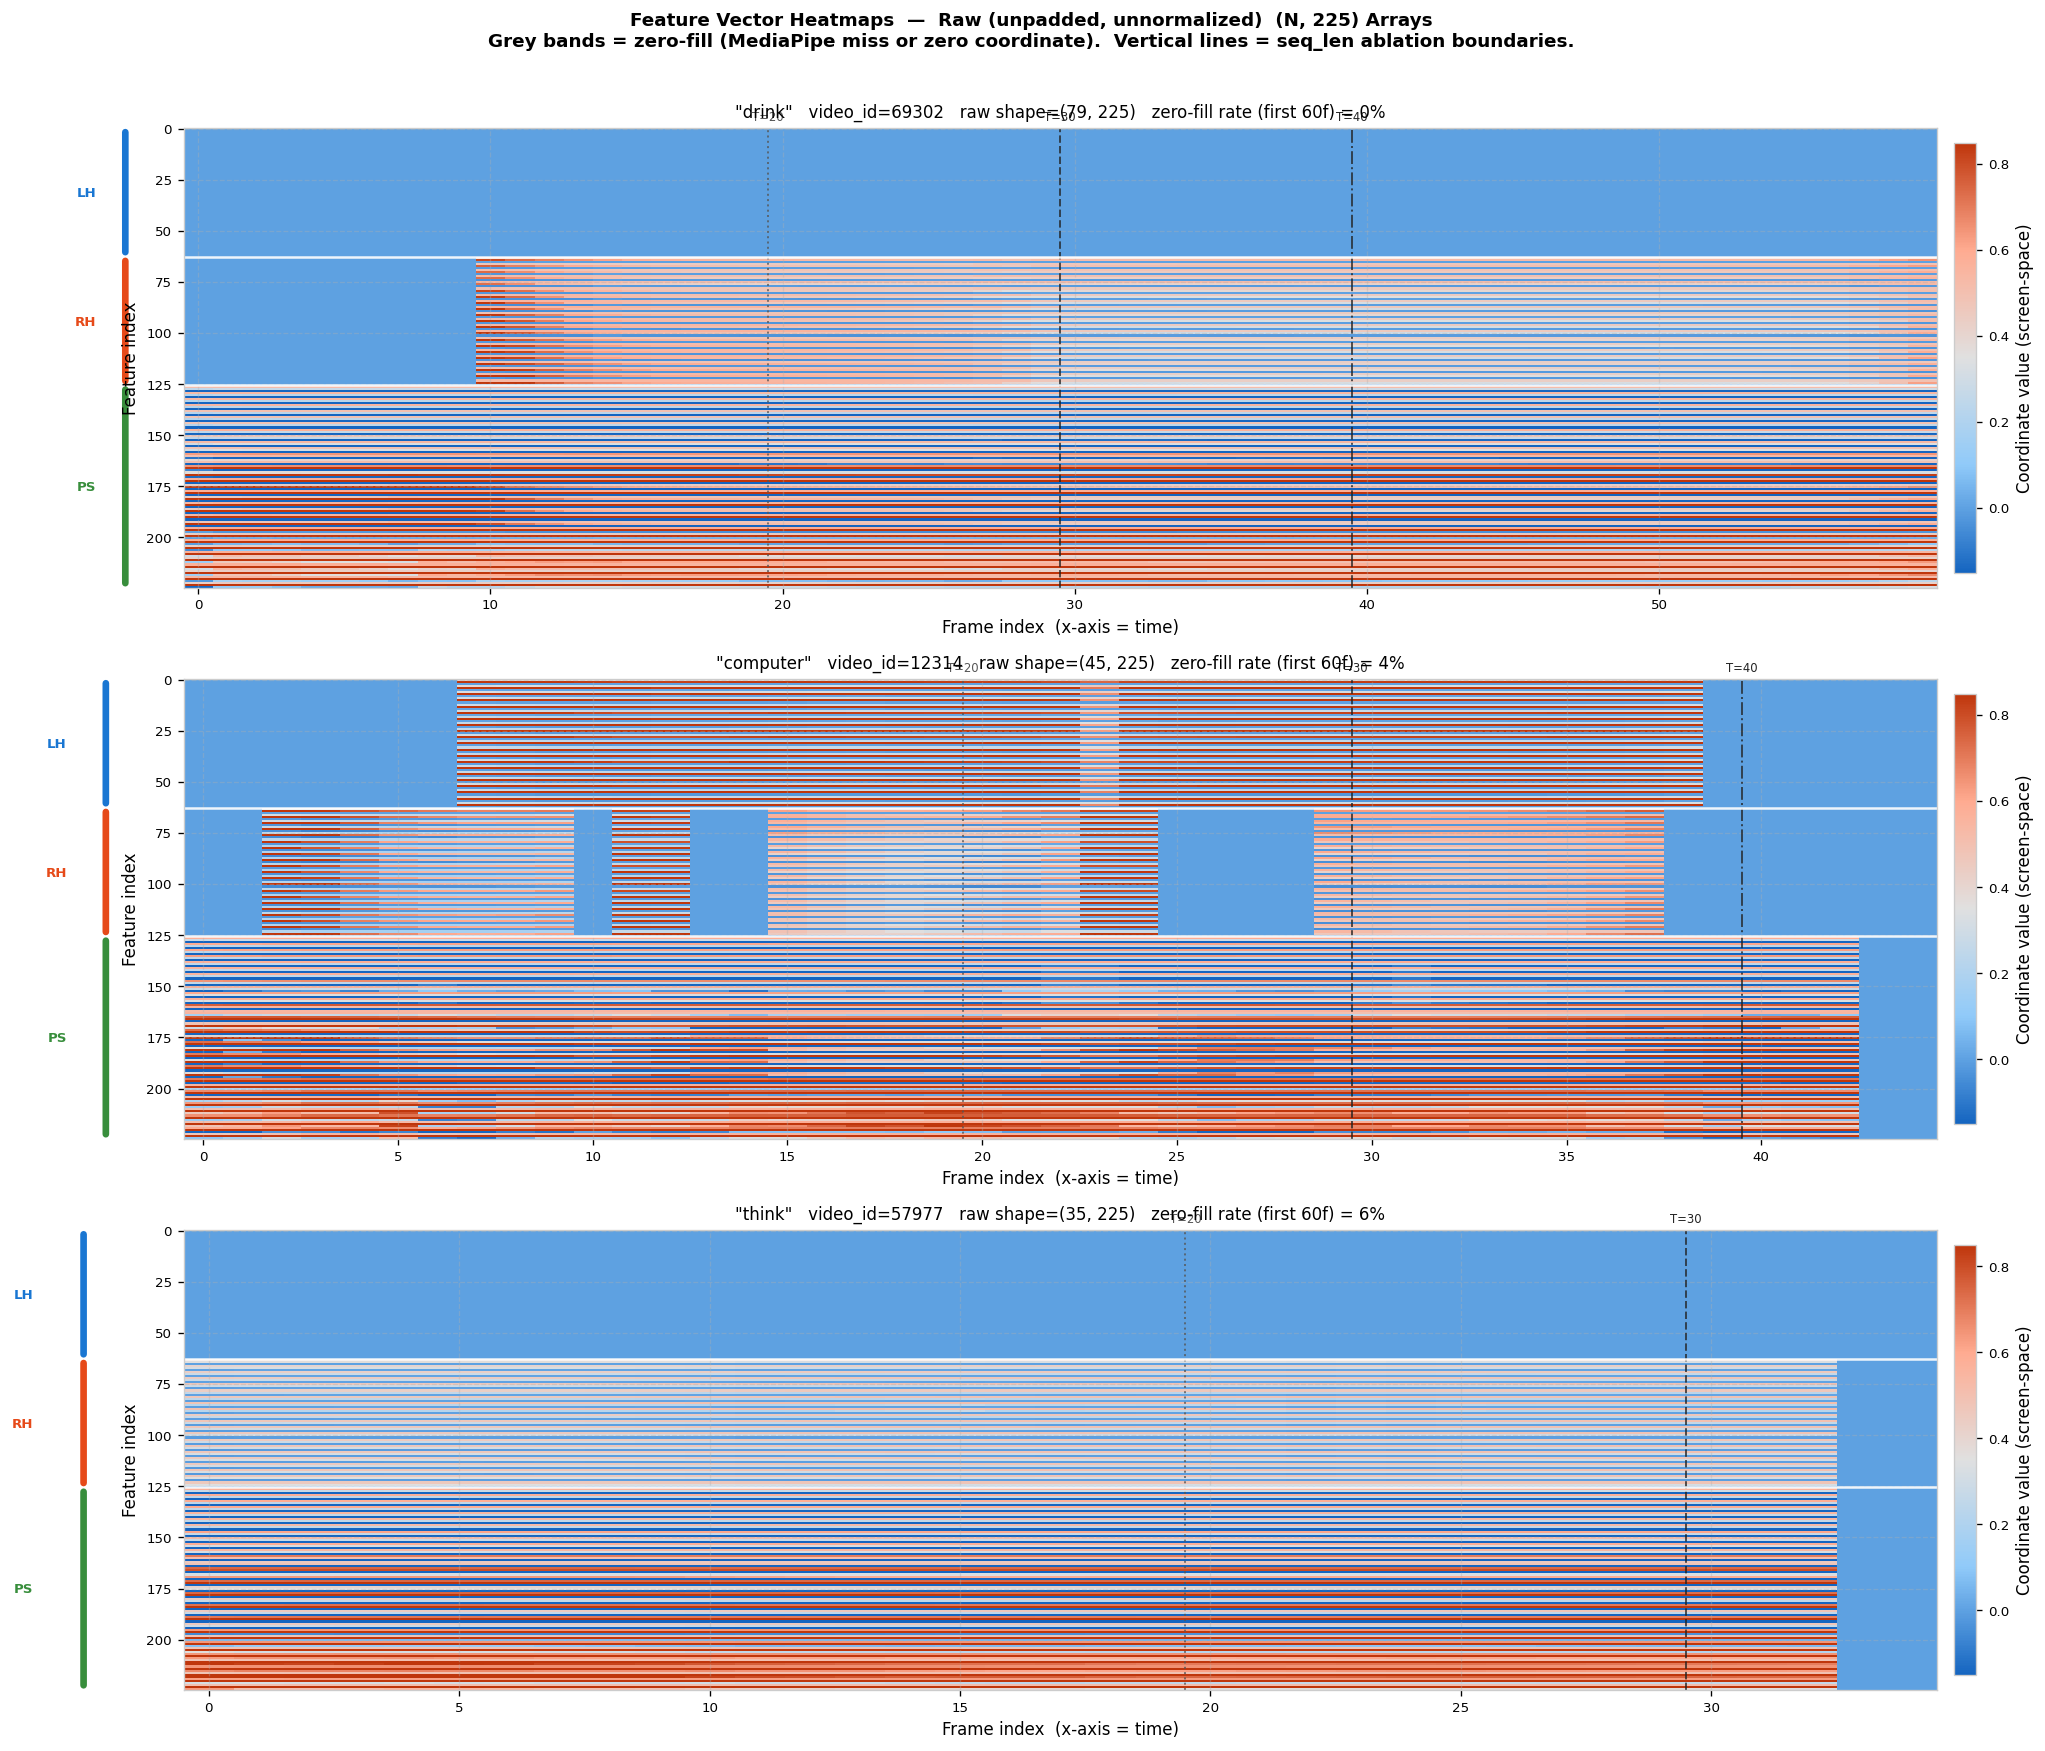

✓  Saved: nb02_feature_heatmap.png
   drink            shape=(79, 225)        zero_pct=37.6%  (includes both zero-fill and near-zero legitimate coords)
   computer         shape=(45, 225)        zero_pct=20.0%  (includes both zero-fill and near-zero legitimate coords)
   think            shape=(35, 225)        zero_pct=32.1%  (includes both zero-fill and near-zero legitimate coords)


In [6]:
"""
Feature Vector Heatmap (N × 225)

Visualises the raw landmark array as a 2D heatmap where:
  x-axis  = frame index (time)
  y-axis  = feature index (0=LH start, 63=RH start, 126=pose start, 224=pose end)

Each colour encodes the coordinate value (approximately in [0,1] for x/y, small
negative/positive for z). Bright rows = detected; dark uniform rows = zero-fill.

Shown for 3 signs with contrasting properties. Seq-len ablation boundaries
(T=20, 30, 40) are overlaid as vertical lines.
"""

def get_best_clip(sign: str, prefer_split: str = "train") -> tuple[np.ndarray | None, str]:
    """Return (array, video_id) for the clip with lowest missing_both_pct."""
    _c = INV_USABLE[INV_USABLE["sign_label"] == sign]
    _t = _c[_c["split"] == prefer_split]
    _pool = _t if not _t.empty else _c
    if _pool.empty:
        return None, ""
    _row = _pool.sort_values("missing_both_pct").iloc[0]
    return load_npy(_row.get("output_path", "")), str(_row.get("video_id", ""))


# Select 3 signs with varied motion profiles
_HMAP_CANDIDATES = ["drink", "computer", "think", "book", "go", "help", "mother"]
_hmap_clips = []
for _cand in _HMAP_CANDIDATES:
    _arr, _vid = get_best_clip(_cand)
    if _arr is not None and _arr.shape[0] > 5:
        _hmap_clips.append((_cand, _arr, _vid))
    if len(_hmap_clips) == 3:
        break

if not _hmap_clips:
    print("⚠  No usable clips for heatmap — check landmark_inventory.csv")
else:
    _N_ROW = len(_hmap_clips)
    fig    = plt.figure(figsize=(17, 4.8 * _N_ROW))

    for _ri, (_sign, _arr, _vid) in enumerate(_hmap_clips):
        _disp = _arr[:60].T          # (225, min(N,60)) — transpose for imshow
        _N    = _disp.shape[1]

        ax = fig.add_subplot(_N_ROW, 1, _ri + 1)

        # Custom diverging colormap: grey=0 (zero-fill), warm=positive, cool=negative
        _cmap = LinearSegmentedColormap.from_list(
            "lm_hmap", ["#1565C0", "#90CAF9", "#E0E0E0", "#FFAB91", "#BF360C"]
        )
        _im = ax.imshow(
            _disp, aspect="auto", cmap=_cmap,
            vmin=-0.15, vmax=0.85, interpolation="nearest",
        )

        # Band annotation bars on the left
        for _bname, _sl, _bc in [
            ("LH", LEFT_HAND_SLICE,  BAND_COLORS["left_hand"]),
            ("RH", RIGHT_HAND_SLICE, BAND_COLORS["right_hand"]),
            ("PS", POSE_SLICE,       BAND_COLORS["pose"]),
        ]:
            ax.add_patch(mpatches.FancyArrowPatch(
                (-2.5, _sl.start), (-2.5, _sl.stop - 1),
                arrowstyle="-", color=_bc, linewidth=4, clip_on=False,
            ))
            ax.text(
                -3.5, (_sl.start + _sl.stop) / 2, _bname,
                ha="right", va="center", fontsize=8,
                color=_bc, fontweight="bold", clip_on=False,
            )

        # Seq-len boundaries
        for _sl, _ls, _col, _lbl in [
            (20, ":",  "#555", "T=20"),
            (30, "--", "#222", "T=30"),
            (40, "-.", "#222", "T=40"),
        ]:
            if _sl <= _N:
                ax.axvline(_sl - 0.5, color=_col, linestyle=_ls, linewidth=1.2, alpha=0.75)
                ax.text(_sl - 0.5, -4, _lbl, ha="center", fontsize=7,
                        color=_col, clip_on=False)

        # Horizontal band delimiters
        for _boundary in [LEFT_HAND_SLICE.stop, RIGHT_HAND_SLICE.stop]:
            ax.axhline(_boundary - 0.5, color="white", linewidth=1.5, alpha=0.9)

        plt.colorbar(_im, ax=ax, fraction=0.012, pad=0.01,
                     label="Coordinate value (screen-space)")

        _miss_pct = float((_arr[:60] == 0).all(axis=1).mean())
        ax.set_title(
            f'"{_sign}"   video_id={_vid}   raw shape={_arr.shape}   '
            f'zero-fill rate (first 60f) = {_miss_pct:.0%}',
            fontsize=10,
        )
        ax.set_xlabel("Frame index  (x-axis = time)")
        ax.set_ylabel("Feature index")
        ax.set_ylim(FEATURE_SIZE - 0.5, -0.5)

    fig.suptitle(
        "Feature Vector Heatmaps  —  Raw (unpadded, unnormalized)  (N, 225) Arrays\n"
        "Grey bands = zero-fill (MediaPipe miss or zero coordinate).  "
        "Vertical lines = seq_len ablation boundaries.",
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "nb02_feature_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved: nb02_feature_heatmap.png")
    for _sign, _arr, _vid in _hmap_clips:
        _z = float((_arr == 0).mean())
        print(f"   {_sign:15s}  shape={str(_arr.shape):15s}  zero_pct={_z:.1%}  "
              f"(includes both zero-fill and near-zero legitimate coords)")

**7 — Missing Landmark Rate Analysis**

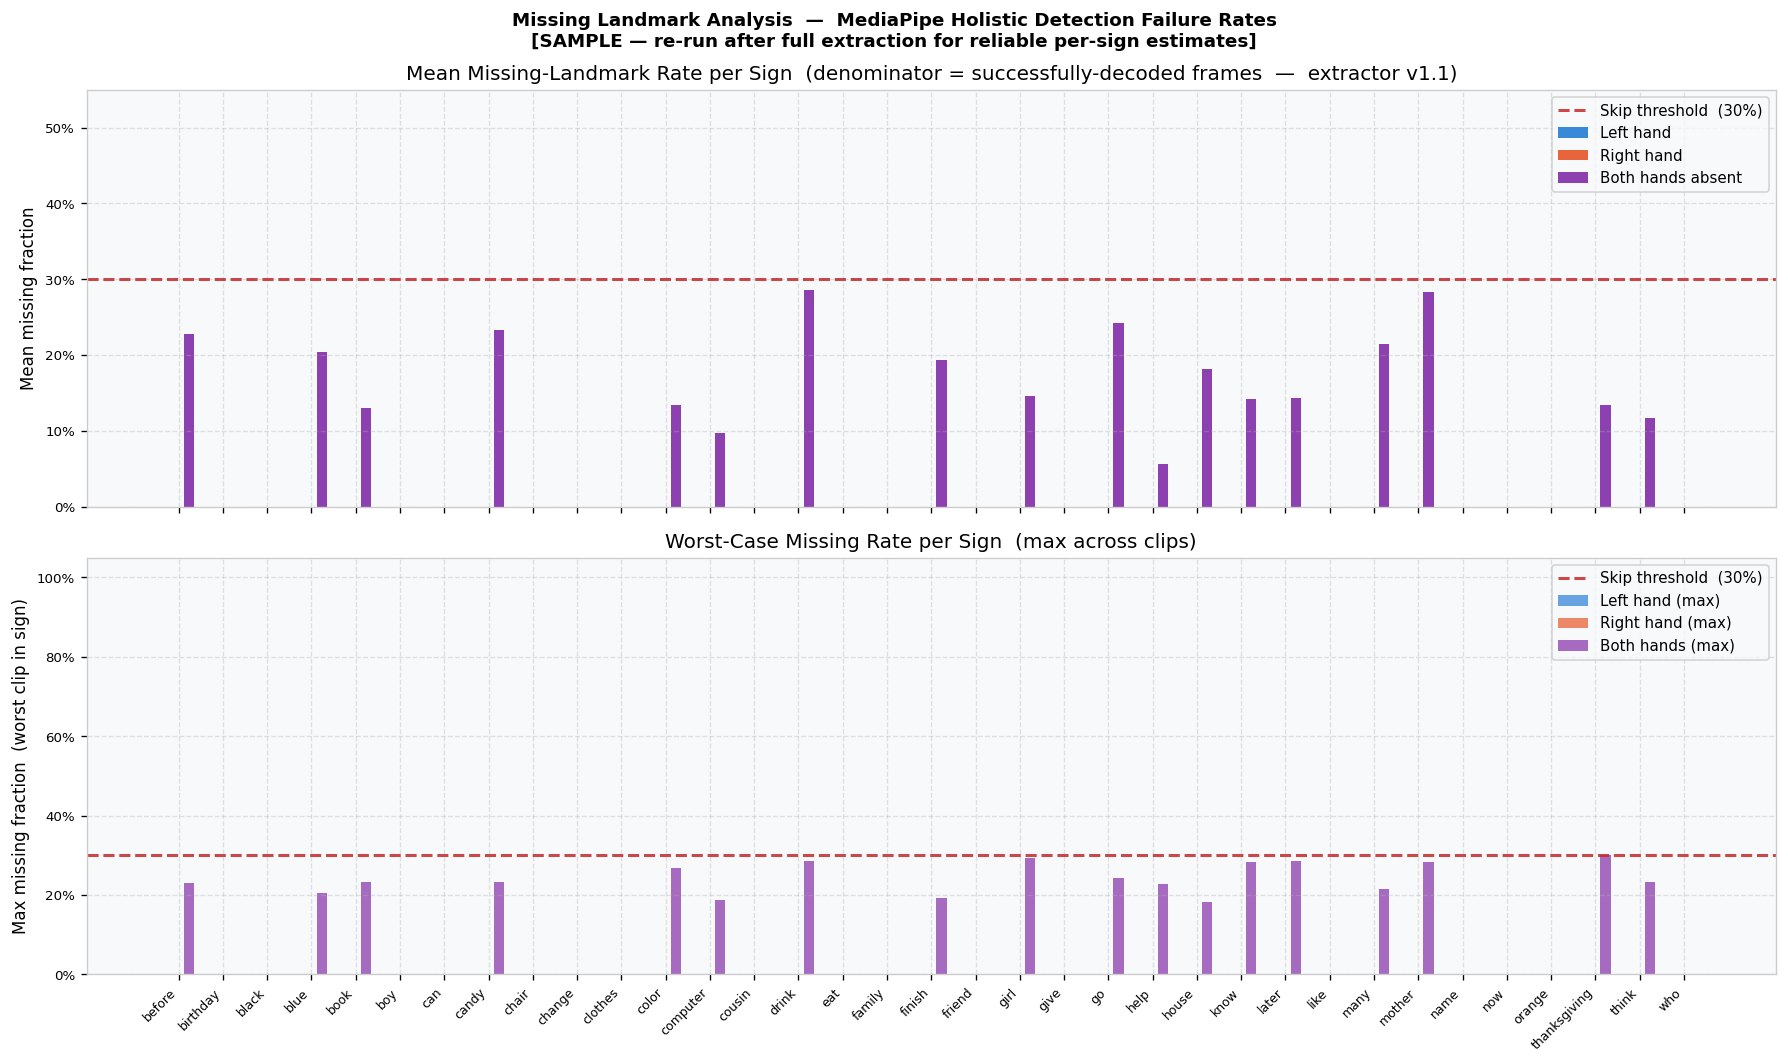

✓  Saved: nb02_missing_landmark_analysis.png

Global missing rates across 50 usable clips:
  missing_left_pct            :  mean=0.00%  median=0.00%  max=0.00%
  missing_right_pct           :  mean=0.00%  median=0.00%  max=0.00%
  missing_pose_pct            :  mean=0.00%  median=0.00%  max=0.00%
  missing_both_pct            :  mean=9.95%  median=0.00%  max=30.00%

⚠  High-risk signs (mean both-hands-absent > 15%):
     drink            mean=28.6%  max=28.6%
     mother           mean=28.4%  max=28.4%
     go               mean=24.2%  max=24.2%
     candy            mean=23.3%  max=23.3%
     before           mean=22.8%  max=23.1%
     many             mean=21.4%  max=21.4%
     blue             mean=20.4%  max=20.4%
     finish           mean=19.4%  max=19.4%
     house            mean=18.2%  max=18.2%


In [7]:
"""
Per-sign detection failure rates, computed over SUCCESSFULLY-DECODED frames
only (extractor v1.1 semantics). Codec errors in decode_failure_frames are
excluded from the denominator.

Surfaces: which signs have poor hand detection (→ more augmentation needed),
and whether the 30% skip threshold is appropriate given the observed rates.
"""

# ── Aggregate per sign ────────────────────────────────────────────────────────
_MISS_COLS = ["missing_left_pct", "missing_right_pct",
              "missing_pose_pct", "missing_both_pct"]

_per_sign_miss = (
    INV_USABLE.groupby("sign_label")[_MISS_COLS]
    .agg(["mean", "max", "std"])
)
_per_sign_miss.columns = ["_".join(c) for c in _per_sign_miss.columns]
_per_sign_miss["class_idx"] = _per_sign_miss.index.map(CLASSES_INV)
_per_sign_miss              = _per_sign_miss.sort_values("class_idx")

def _col(base: str, stat: str) -> np.ndarray:
    """Safe column extraction — returns zeros if sign not in index."""
    col = f"{base}_{stat}"
    return np.array([
        _per_sign_miss.loc[s, col] if s in _per_sign_miss.index else 0.0
        for s in ALL_SIGNS
    ])

_x = np.arange(N_CLASSES)
_w = 0.23

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

# Top panel: mean missing rates by landmark type
ax = axes[0]
ax.bar(_x - _w,   _col("missing_left_pct",  "mean"), _w,
       color=BAND_COLORS["left_hand"],  alpha=0.85, label="Left hand")
ax.bar(_x,        _col("missing_right_pct", "mean"), _w,
       color=BAND_COLORS["right_hand"], alpha=0.85, label="Right hand")
ax.bar(_x + _w,   _col("missing_both_pct",  "mean"), _w,
       color="#7B1FA2", alpha=0.85, label="Both hands absent")
ax.axhline(0.30, color="#C62828", linestyle="--", linewidth=1.8, alpha=0.85,
           label="Skip threshold  (30%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel("Mean missing fraction")
ax.set_title(
    "Mean Missing-Landmark Rate per Sign  "
    "(denominator = successfully-decoded frames  —  extractor v1.1)"
)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, max(0.55, _col("missing_both_pct", "mean").max() * 1.25))

# Bottom panel: worst-clip missing rates
ax = axes[1]
ax.bar(_x - _w,   _col("missing_left_pct",  "max"), _w,
       color=BAND_COLORS["left_hand"],  alpha=0.65, label="Left hand (max)")
ax.bar(_x,        _col("missing_right_pct", "max"), _w,
       color=BAND_COLORS["right_hand"], alpha=0.65, label="Right hand (max)")
ax.bar(_x + _w,   _col("missing_both_pct",  "max"), _w,
       color="#7B1FA2", alpha=0.65, label="Both hands (max)")
ax.axhline(0.30, color="#C62828", linestyle="--", linewidth=1.8, alpha=0.85,
           label="Skip threshold  (30%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylabel("Max missing fraction  (worst clip in sign)")
ax.set_title("Worst-Case Missing Rate per Sign  (max across clips)")
ax.set_xticks(_x)
ax.set_xticklabels(ALL_SIGNS, rotation=45, ha="right", fontsize=7.5)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1.05)

plt.suptitle(
    "Missing Landmark Analysis  —  MediaPipe Holistic Detection Failure Rates\n"
    f"{'[SAMPLE — re-run after full extraction for reliable per-sign estimates]' if IS_SAMPLE else '[FULL DATASET]'}",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb02_missing_landmark_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb02_missing_landmark_analysis.png")

# ── Text summary ──────────────────────────────────────────────────────────────
print(f"\nGlobal missing rates across {len(INV_USABLE)} usable clips:")
for _col_name in _MISS_COLS:
    _v = INV_USABLE[_col_name]
    print(f"  {_col_name:28s}:  mean={_v.mean():.2%}  "
          f"median={_v.median():.2%}  max={_v.max():.2%}")

_high_risk = _per_sign_miss[_per_sign_miss["missing_both_pct_mean"] > 0.15].sort_values(
    "missing_both_pct_mean", ascending=False
)
if not _high_risk.empty:
    print(f"\n⚠  High-risk signs (mean both-hands-absent > 15%):")
    for _sn, _r in _high_risk.iterrows():
        print(f"     {_sn:15s}  mean={_r['missing_both_pct_mean']:.1%}  "
              f"max={_r['missing_both_pct_max']:.1%}")
else:
    print(f"\n✓  No signs with mean both-hands-absent > 15%")

**8 — Landmark Quality Heatmap**

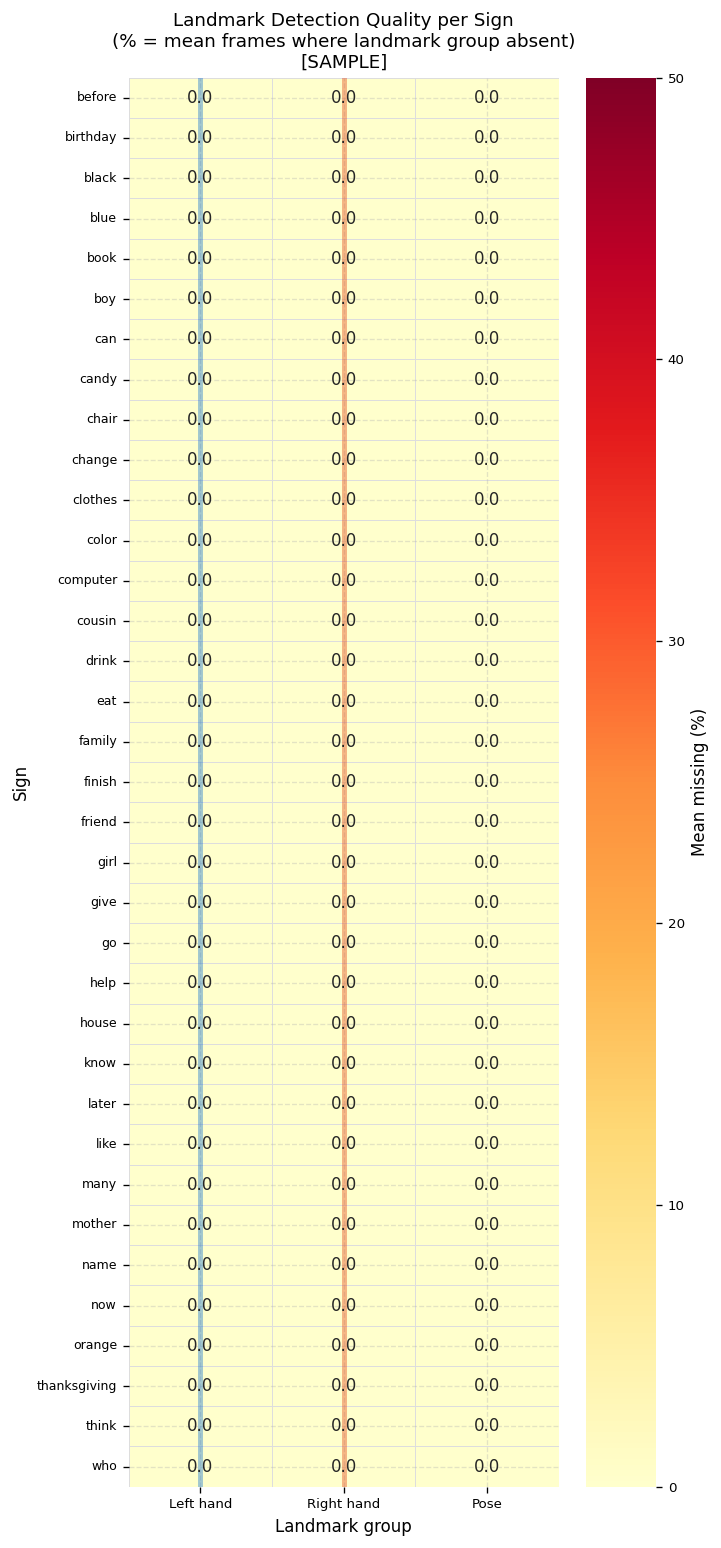

✓  Saved: nb02_landmark_quality_heatmap.png
  Left hand   : mean=0.0%  worst='before' (0.0%)
  Right hand  : mean=0.0%  worst='before' (0.0%)
  Pose        : mean=0.0%  worst='before' (0.0%)

⚠ Unusual: pose missing rate higher than hand detection — check video quality


In [8]:
"""
Landmark Quality Heatmap (sign × detector type)

Compact overview of detection reliability across all 35 signs.
The three columns (Left Hand / Right Hand / Pose) directly map to
the three feature bands in the 225-value vector.

Interpretation:
  0%  → hand/pose always detected in this sign
  >30% → frequently missed; zero-fill dominant in this band
"""

# ── Build quality matrix ───────────────────────────────────────────────────────
_qual_matrix = pd.DataFrame(index=ALL_SIGNS)
for _col_name, _disp in [
    ("missing_left_pct_mean",  "Left hand"),
    ("missing_right_pct_mean", "Right hand"),
    ("missing_pose_pct_mean",  "Pose"),
]:
    _qual_matrix[_disp] = [
        _per_sign_miss.loc[s, _col_name]
        if s in _per_sign_miss.index else 0.0
        for s in ALL_SIGNS
    ]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 13))
_annot_data = (_qual_matrix * 100).round(1)

sns.heatmap(
    _annot_data,
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    linecolor="#dddddd",
    cbar_kws={"label": "Mean missing (%)"},
    vmin=0, vmax=50,
)
# Mark the skip threshold
ax.axvline(0.5,  color=BAND_COLORS["left_hand"],  linewidth=3, alpha=0.4)
ax.axvline(1.5,  color=BAND_COLORS["right_hand"], linewidth=3, alpha=0.4)

ax.set_title(
    "Landmark Detection Quality per Sign\n"
    "(% = mean frames where landmark group absent)\n"
    f"{'[SAMPLE]' if IS_SAMPLE else '[FULL DATASET]'}",
    fontsize=11,
)
ax.set_xlabel("Landmark group")
ax.set_ylabel("Sign")
ax.tick_params(axis="y", labelsize=7.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb02_landmark_quality_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb02_landmark_quality_heatmap.png")

# ── Column-level summary ──────────────────────────────────────────────────────
for _col in _qual_matrix.columns:
    _v = _qual_matrix[_col]
    print(f"  {_col:12s}: mean={_v.mean():.1%}  "
          f"worst='{_v.idxmax()}' ({_v.max():.1%})")

if _qual_matrix["Pose"].mean() < _qual_matrix["Left hand"].mean():
    print("\n✓ Pose detection more reliable than hands (expected for WLASL video quality)")
else:
    print("\n⚠ Unusual: pose missing rate higher than hand detection — check video quality")

**9 — Sequence Length Distribution**

Frame count statistics  (35 usable clips):
  Mean   : 51.4 frames  (1.7s @ 30fps)
  Median : 51.0 frames
  Std    : 16.9 frames
  Min    : 22
  Max    : 79

 seq_len   clips fully covered   mean content captured  note
      20                  0.0%                   43.5%  
      30                  2.9%                   64.3%  
      40                 34.3%                   79.5%  
      60                 71.4%                   94.8%  ← captures most content


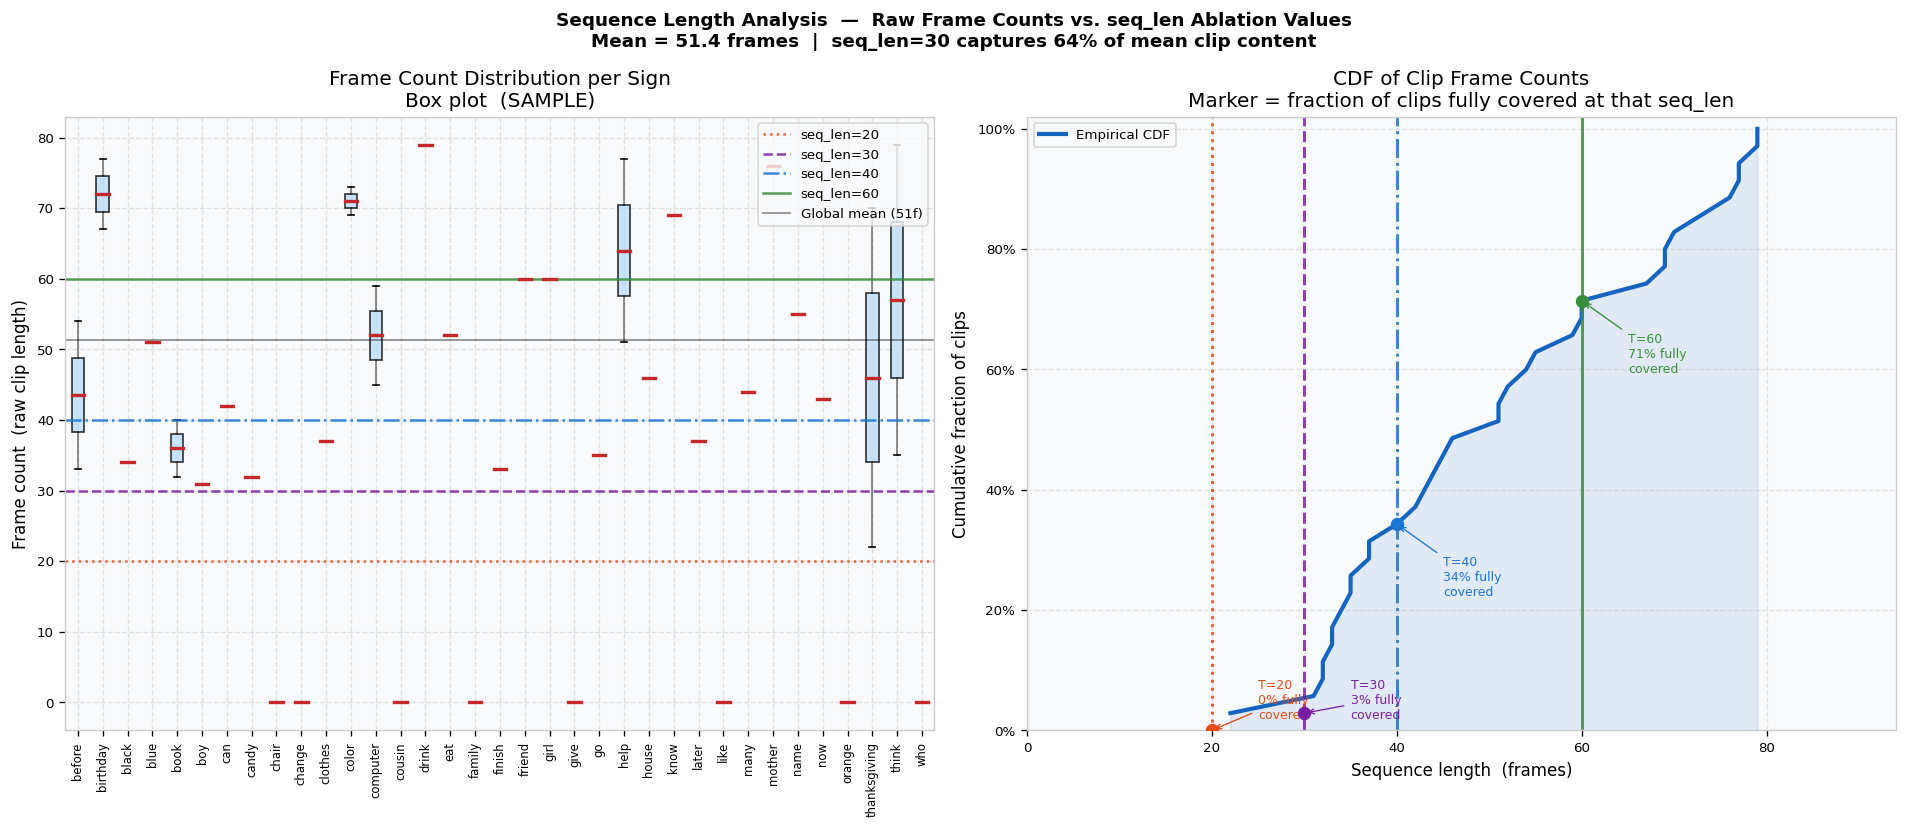

✓  Saved: nb02_sequence_length_distribution.png


In [9]:
"""
Dual analysis:
  1. Box/violin plot of raw frame counts per sign (shows which signs
     have longer/shorter clips and the within-sign spread)
  2. CDF of frame counts with seq_len ablation markers (answers: at
     seq_len=30, what fraction of clips are fully covered?)

Key design decision output: confirms whether seq_len=30 or seq_len=60
is the more appropriate default, given the mean of ~65.7 frames/clip.
"""

_frame_data = INV_USABLE[INV_USABLE["num_frames"] > 0].copy()

# ── Global statistics ─────────────────────────────────────────────────────────
_gm  = _frame_data["num_frames"].mean()
_gmd = _frame_data["num_frames"].median()
_gs  = _frame_data["num_frames"].std()

print(f"Frame count statistics  ({len(_frame_data)} usable clips):")
print(f"  Mean   : {_gm:.1f} frames  ({_gm / 30:.1f}s @ 30fps)")
print(f"  Median : {_gmd:.1f} frames")
print(f"  Std    : {_gs:.1f} frames")
print(f"  Min    : {_frame_data['num_frames'].min()}")
print(f"  Max    : {_frame_data['num_frames'].max()}")

# ── Coverage table ────────────────────────────────────────────────────────────
print(f"\n{'seq_len':>8}  {'clips fully covered':>20}  {'mean content captured':>22}  note")
for _sl in SEQ_LENS:
    _pct_full = float((_frame_data["num_frames"] <= _sl).mean())
    _mean_cov = float(
        (_frame_data["num_frames"].clip(upper=_sl) /
         _frame_data["num_frames"].replace(0, 1)).mean()
    )
    _note = ""
    if _mean_cov < 0.30:
        _note = "← sees <30% of sign content"
    elif _mean_cov > 0.90:
        _note = "← captures most content"
    print(f"  {_sl:>6}  {_pct_full:>20.1%}  {_mean_cov:>22.1%}  {_note}")

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: per-sign distribution ───────────────────────────────────────────────
ax = axes[0]
_plot_data  = []
_pos_labels = []
for _s in ALL_SIGNS:
    _d = _frame_data[_frame_data["sign_label"] == _s]["num_frames"].values
    _plot_data.append(_d if len(_d) > 0 else np.array([0]))
    _pos_labels.append(_s)

_positions = list(range(N_CLASSES))

# Violin if enough data; fallback to box for sample
if not IS_SAMPLE and len(_frame_data) > N_CLASSES * 3:
    _parts = ax.violinplot(
        _plot_data, positions=_positions, showmedians=True, showextrema=True
    )
    for _pc in _parts["bodies"]:
        _pc.set_facecolor("#90CAF9")
        _pc.set_alpha(0.7)
    _parts["cmedians"].set_color("red")
else:
    ax.boxplot(
        _plot_data, positions=_positions, widths=0.5, patch_artist=True,
        boxprops=dict(facecolor="#BBDEFB", alpha=0.8),
        medianprops=dict(color="#C62828", linewidth=2),
        whiskerprops=dict(alpha=0.5),
        flierprops=dict(marker="o", markersize=2, alpha=0.4),
    )

for _sl, _col, _ls in [
    (20, "#E64A19", ":"),
    (30, "#7B1FA2", "--"),
    (40, "#1976D2", "-."),
    (60, "#388E3C", "-"),
]:
    ax.axhline(_sl, color=_col, linestyle=_ls, linewidth=1.5, alpha=0.85,
               label=f"seq_len={_sl}")
ax.axhline(_gm, color="black", linestyle="-", linewidth=1, alpha=0.45,
           label=f"Global mean ({_gm:.0f}f)")

ax.set_xticks(_positions)
ax.set_xticklabels(_pos_labels, rotation=90, fontsize=7)
ax.set_ylabel("Frame count  (raw clip length)")
ax.set_title(f"Frame Count Distribution per Sign\n"
             f"{'Box' if IS_SAMPLE else 'Violin'} plot  ({'SAMPLE' if IS_SAMPLE else 'FULL'})")
ax.legend(loc="upper right", fontsize=8)

# ── Right: CDF ────────────────────────────────────────────────────────────────
ax = axes[1]
_sf  = np.sort(_frame_data["num_frames"].values)
_cdf = np.arange(1, len(_sf) + 1) / len(_sf)
ax.plot(_sf, _cdf, color="#1565C0", linewidth=2.5, label="Empirical CDF")
ax.fill_between(_sf, _cdf, alpha=0.10, color="#1565C0")

for _sl, _col, _ls in [
    (20, "#E64A19", ":"),
    (30, "#7B1FA2", "--"),
    (40, "#1976D2", "-."),
    (60, "#388E3C", "-"),
]:
    _pct = float((_frame_data["num_frames"] <= _sl).mean())
    ax.axvline(_sl, color=_col, linestyle=_ls, linewidth=1.8, alpha=0.85)
    ax.plot(_sl, _pct, "o", color=_col, markersize=7, zorder=5)
    ax.annotate(
        f"T={_sl}\n{_pct:.0%} fully\ncovered",
        xy=(_sl, _pct),
        xytext=(_sl + 5, max(_pct - 0.12, 0.02)),
        fontsize=7.5, color=_col,
        arrowprops=dict(arrowstyle="->", color=_col, lw=0.8),
    )

ax.set_xlabel("Sequence length  (frames)")
ax.set_ylabel("Cumulative fraction of clips")
ax.set_title("CDF of Clip Frame Counts\n"
             "Marker = fraction of clips fully covered at that seq_len")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
_xlim_max = min(int(_sf.max()) + 15, 200)
ax.set_xlim(0, _xlim_max)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8)

plt.suptitle(
    "Sequence Length Analysis  —  Raw Frame Counts vs. seq_len Ablation Values\n"
    f"Mean = {_gm:.1f} frames  |  seq_len=30 captures "
    f"{float((_frame_data['num_frames'].clip(upper=30) / _frame_data['num_frames'].replace(0,1)).mean()):.0%} of mean clip content",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb02_sequence_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb02_sequence_length_distribution.png")

**10 — Decode Failure Analysis (Extractor v1.1)**

DECODE FAILURE ANALYSIS  —  extractor v1.1
Decode failures = OpenCV codec errors (ret=False from cap.read())
These are NOT MediaPipe detection failures.
v1.1 excludes them from missing_pct denominator.

  Total frames (usable clips)    : 1,799
  Total decode failures          : 70
  Global decode-failure rate     : 3.891%
  ⚠ >1% — investigate codec compatibility on this OS/environment

  Clips with ≥1 decode failure   : 35 / 50

  Top clips by decode failures:
 video_id sign_label split  num_frames  decode_failure_frames  missing_both_pct
     5729     before train          54                      2            0.2308
    37585       name train          55                      2            0.0000
    27213       help train          51                      2            0.0000
    28161      house train          46                      2            0.1818
    31900       know train          69                      2            0.2836
    32322      later train          37                

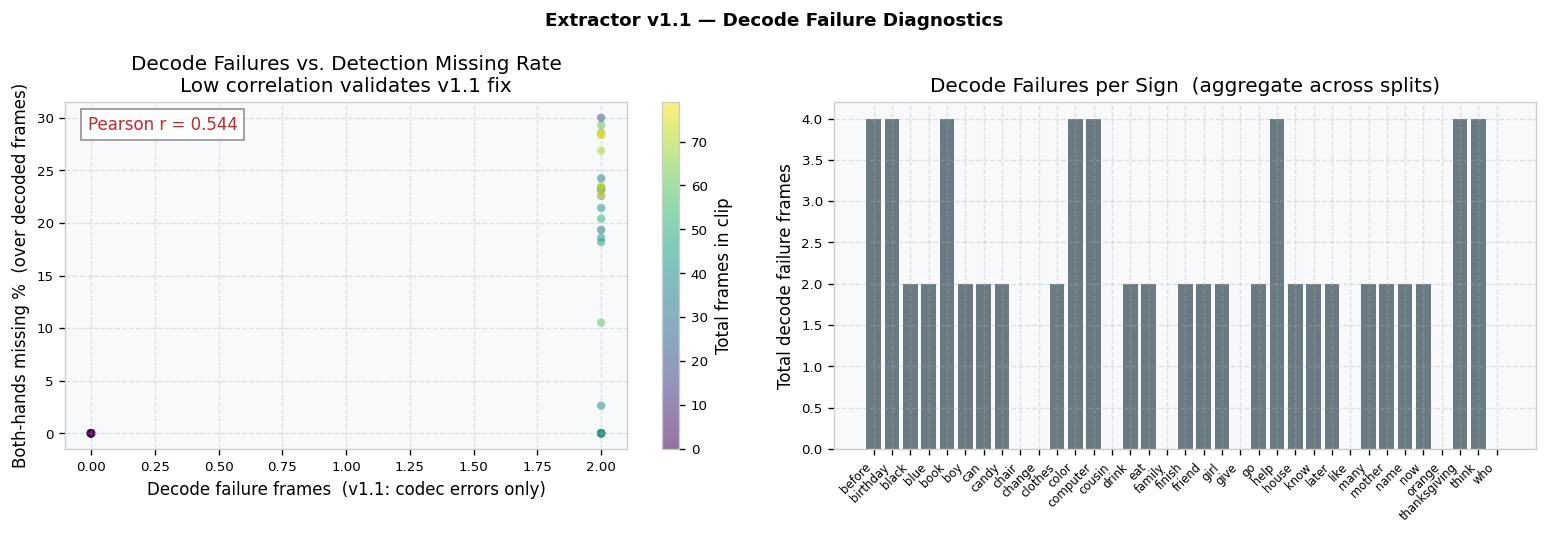


✓  Saved: nb02_decode_failure_analysis.png


In [10]:
"""
Decode Failure Analysis  (extractor schema v1.1)

In v1.0 the bug: codec read failures (ret=False from cv2.read) were counted
as frames where 'both hands are absent', inflating missing_pct and causing
valid clips to be incorrectly skipped.

v1.1 fix: decode_failure_frames are tracked separately and excluded from
the missing_pct denominator. This cell validates the fix is in effect.

Expected: low correlation between decode_failure_frames and missing_both_pct.
High correlation would indicate the bug is still present.
"""

print("=" * 60)
print("DECODE FAILURE ANALYSIS  —  extractor v1.1")
print("=" * 60)
print("Decode failures = OpenCV codec errors (ret=False from cap.read())")
print("These are NOT MediaPipe detection failures.")
print("v1.1 excludes them from missing_pct denominator.")
print()

if "decode_failure_frames" not in INV_USABLE.columns:
    print("⚠  decode_failure_frames column absent from landmark_inventory.csv")
    print("   This suggests an older pipeline was used or the column was not")
    print("   written. Re-run Stage 3 with the current extractor to enable this.")
else:
    _tot_frames   = INV_USABLE["num_frames"].sum()
    _tot_dec_fail = INV_USABLE["decode_failure_frames"].sum()
    _dec_rate     = _tot_dec_fail / max(_tot_frames, 1)

    print(f"  Total frames (usable clips)    : {_tot_frames:,}")
    print(f"  Total decode failures          : {_tot_dec_fail:,}")
    print(f"  Global decode-failure rate     : {_dec_rate:.3%}")

    if _dec_rate < 0.001:
        print("  ✓ <0.1% decode failure rate — codec handling is clean")
    elif _dec_rate < 0.01:
        print("  ✓ <1% — transient codec errors, within expected range for WLASL")
    else:
        print("  ⚠ >1% — investigate codec compatibility on this OS/environment")

    _n_clips_with_df = (INV_USABLE["decode_failure_frames"] > 0).sum()
    print(f"\n  Clips with ≥1 decode failure   : {_n_clips_with_df} / {len(INV_USABLE)}")

    if _n_clips_with_df > 0:
        _worst_df = (
            INV_USABLE[INV_USABLE["decode_failure_frames"] > 0]
            .sort_values("decode_failure_frames", ascending=False)
            [["video_id", "sign_label", "split", "num_frames",
              "decode_failure_frames", "missing_both_pct"]]
            .head(8)
        )
        print(f"\n  Top clips by decode failures:")
        print(_worst_df.to_string(index=False))

    # ── Scatter: decode_failure_frames vs missing_both_pct ────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # Left: scatter
    ax = axes[0]
    _sc = ax.scatter(
        INV_USABLE["decode_failure_frames"],
        INV_USABLE["missing_both_pct"] * 100,
        c=INV_USABLE["num_frames"],
        cmap="viridis", alpha=0.55, s=25, edgecolors="none",
    )
    plt.colorbar(_sc, ax=ax, label="Total frames in clip")
    ax.set_xlabel("Decode failure frames  (v1.1: codec errors only)")
    ax.set_ylabel("Both-hands missing %  (over decoded frames)")
    ax.set_title("Decode Failures vs. Detection Missing Rate\n"
                 "Low correlation validates v1.1 fix")

    if len(INV_USABLE) > 5:
        _corr = INV_USABLE["decode_failure_frames"].corr(INV_USABLE["missing_both_pct"])
        _msg  = f"Pearson r = {_corr:.3f}"
        _clr  = "#388E3C" if abs(_corr) < 0.3 else "#C62828"
        ax.text(0.04, 0.92, _msg, transform=ax.transAxes, fontsize=10,
                color=_clr, bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray"))
        print(f"\n  Pearson r (decode_failures, missing_both) = {_corr:.4f}")
        if abs(_corr) < 0.3:
            print("  ✓ Low correlation — v1.1 separation is working correctly")
        else:
            print("  ⚠ Unexpected correlation — verify extractor schema version")

    # Right: decode failures per sign
    ax = axes[1]
    _df_by_sign = (
        INV_USABLE.groupby("sign_label")["decode_failure_frames"]
        .sum()
        .reindex(ALL_SIGNS, fill_value=0)
    )
    _xp = np.arange(N_CLASSES)
    ax.bar(_xp, _df_by_sign.values, color="#455A64", alpha=0.8)
    ax.set_xticks(_xp)
    ax.set_xticklabels(ALL_SIGNS, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Total decode failure frames")
    ax.set_title("Decode Failures per Sign  (aggregate across splits)")

    plt.suptitle(
        f"Extractor v{EXTRACTOR_SCHEMA_VERSION} — Decode Failure Diagnostics",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "nb02_decode_failure_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n✓  Saved: nb02_decode_failure_analysis.png")

**11 — Wrist-Relative Normalization Validation**

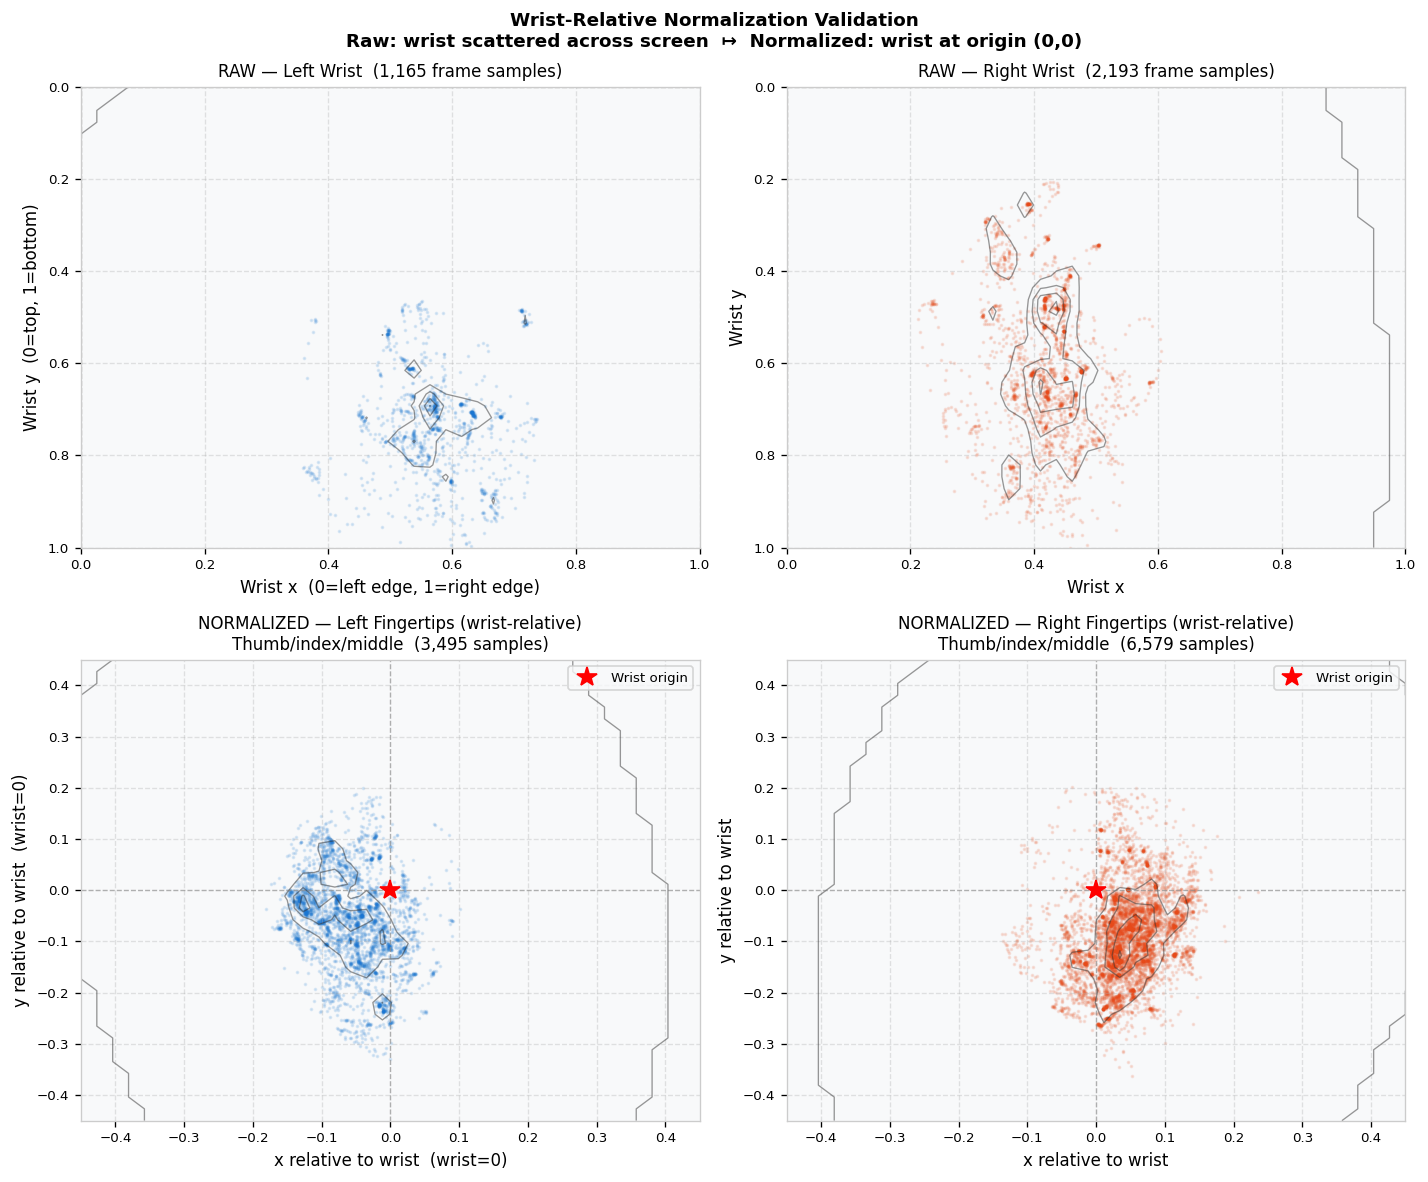

✓  Saved: nb02_wrist_normalization.png

Raw left wrist x ∈ [0.36, 0.74]  std=0.074
Raw left wrist y ∈ [0.46, 1.08]  std=0.116
Normalized LH fingertip x ∈ [-0.18, 0.10]  std=0.050

✓ Raw wrist positions spread across screen space — normalization removes this positional noise.
  Normalized coordinates encode only hand shape and relative motion.


In [11]:
"""
Implements wrist-relative normalization INLINE (Stage 4's FeaturePipeline
will formalize this; this cell is validation only).

Normalization rule (per frame, per hand):
  normalized_landmark[i] = raw_landmark[i] - raw_landmark[WRIST=0]
  → Only applied to frames where the hand is detected (non-zero)
  → Zero-filled frames remain zero (wrist at zero is indistinguishable
    from zero-fill; FeaturePipeline will handle this via detection masking)

Visual validation:
  Raw positions → scattered across [0,1] screen space
  Post-normalization → wrist at origin; relative hand shape preserved
"""

# ── Normalization function (inline — Stage 4 will formalize in FeaturePipeline) ──
def wrist_relative_normalize(arr: np.ndarray) -> np.ndarray:
    """
    Apply per-frame, per-hand wrist-relative normalization to a (N, 225) array.

    Only normalizes frames where the hand is detected (any landmark non-zero).
    Zero-filled frames are passed through unchanged to avoid false origin shifts.

    Parameters
    ----------
    arr : np.ndarray, shape (N, 225), float32

    Returns
    -------
    normalized : np.ndarray, shape (N, 225), float32
    """
    normalized = arr.copy()

    for _hand_slice in (LEFT_HAND_SLICE, RIGHT_HAND_SLICE):
        # Reshape to (N, 21, 3) for vectorized landmark indexing
        _lh = normalized[:, _hand_slice].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)

        # Detection mask: frame is 'detected' iff ANY landmark is non-zero
        _detected = (_lh != 0).any(axis=(1, 2))   # (N,)

        if _detected.sum() == 0:
            continue

        # Wrist position for detected frames: shape (N_det, 1, 3)
        _wrist = _lh[_detected, WRIST_LANDMARK_INDEX, :][:, np.newaxis, :]

        # Vectorized in-place subtraction (only detected frames)
        _lh_out = _lh.copy()
        _lh_out[_detected] = _lh[_detected] - _wrist

        normalized[:, _hand_slice] = _lh_out.reshape(-1, N_HAND_FEATURES)

    return normalized


# ── Collect raw and normalized wrist positions ────────────────────────────────
_raw_lh_wrists, _raw_rh_wrists     = [], []
_norm_lh_tips,  _norm_rh_tips      = [], []
_sign_color_map = {}

_max_clips_to_sample = min(80, len(INV_USABLE))
_sampled = INV_USABLE.sample(_max_clips_to_sample, random_state=42) if len(INV_USABLE) > _max_clips_to_sample else INV_USABLE

for _, _row in _sampled.iterrows():
    _arr = load_npy(_row.get("output_path", ""))
    if _arr is None or _arr.shape[0] == 0:
        continue

    _lh_raw = _arr[:, LEFT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
    _rh_raw = _arr[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)

    _lh_det = (_lh_raw != 0).any(axis=(1, 2))
    _rh_det = (_rh_raw != 0).any(axis=(1, 2))

    # Raw wrist (x,y) positions — frame-level
    _raw_lh_wrists.extend(
        _lh_raw[_lh_det, WRIST_LANDMARK_INDEX, :2].tolist()
    )
    _raw_rh_wrists.extend(
        _rh_raw[_rh_det, WRIST_LANDMARK_INDEX, :2].tolist()
    )

    # Normalized: show FINGERTIP positions (index=8, middle=12) relative to wrist
    _norm = wrist_relative_normalize(_arr)
    _lh_norm = _norm[:, LEFT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
    _rh_norm = _norm[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)

    for _tip in [4, 8, 12]:   # thumb, index, middle fingertips
        _norm_lh_tips.extend(_lh_norm[_lh_det, _tip, :2].tolist())
        _norm_rh_tips.extend(_rh_norm[_rh_det, _tip, :2].tolist())

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(
    "Wrist-Relative Normalization Validation\n"
    "Raw: wrist scattered across screen  ↦  Normalized: wrist at origin (0,0)",
    fontsize=11,
)

def _scatter_panel(ax, points, title, color, xlim, ylim, invert_y=False):
    if not points:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return
    _xs = [p[0] for p in points]
    _ys = [p[1] for p in points]
    ax.scatter(_xs, _ys, s=1.5, alpha=0.12, color=color, rasterized=True)

    # KDE contours if scipy available
    try:
        from scipy.stats import gaussian_kde
        if len(_xs) > 100:
            _kxy = np.vstack([_xs, _ys])
            _kde = gaussian_kde(_kxy, bw_method=0.15)
            _xg, _yg = np.mgrid[xlim[0]:xlim[1]:40j, ylim[0]:ylim[1]:40j]
            _z = _kde(np.vstack([_xg.ravel(), _yg.ravel()])).reshape(40, 40)
            ax.contour(_xg, _yg, _z, levels=4, colors=["#333333"], alpha=0.5, linewidths=0.8)
    except ImportError:
        pass

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    if invert_y:
        ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
    ax.axvline(0, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)

# Row 0: Raw wrist positions (screen space)
_scatter_panel(axes[0, 0], _raw_lh_wrists,
               f"RAW — Left Wrist  ({len(_raw_lh_wrists):,} frame samples)",
               BAND_COLORS["left_hand"], xlim=(0, 1), ylim=(0, 1), invert_y=True)
axes[0, 0].set_xlabel("Wrist x  (0=left edge, 1=right edge)")
axes[0, 0].set_ylabel("Wrist y  (0=top, 1=bottom)")

_scatter_panel(axes[0, 1], _raw_rh_wrists,
               f"RAW — Right Wrist  ({len(_raw_rh_wrists):,} frame samples)",
               BAND_COLORS["right_hand"], xlim=(0, 1), ylim=(0, 1), invert_y=True)
axes[0, 1].set_xlabel("Wrist x")
axes[0, 1].set_ylabel("Wrist y")

# Row 1: Normalized fingertip positions (wrist-relative)
_lim = 0.45
_scatter_panel(axes[1, 0], _norm_lh_tips,
               f"NORMALIZED — Left Fingertips (wrist-relative)\n"
               f"Thumb/index/middle  ({len(_norm_lh_tips):,} samples)",
               BAND_COLORS["left_hand"], xlim=(-_lim, _lim), ylim=(-_lim, _lim))
axes[1, 0].set_xlabel("x relative to wrist  (wrist=0)")
axes[1, 0].set_ylabel("y relative to wrist  (wrist=0)")
axes[1, 0].plot(0, 0, "r*", markersize=12, label="Wrist origin")
axes[1, 0].legend(fontsize=8)

_scatter_panel(axes[1, 1], _norm_rh_tips,
               f"NORMALIZED — Right Fingertips (wrist-relative)\n"
               f"Thumb/index/middle  ({len(_norm_rh_tips):,} samples)",
               BAND_COLORS["right_hand"], xlim=(-_lim, _lim), ylim=(-_lim, _lim))
axes[1, 1].set_xlabel("x relative to wrist")
axes[1, 1].set_ylabel("y relative to wrist")
axes[1, 1].plot(0, 0, "r*", markersize=12, label="Wrist origin")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb02_wrist_normalization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓  Saved: nb02_wrist_normalization.png")

# Quantitative validation
if _raw_lh_wrists:
    _rxs = [p[0] for p in _raw_lh_wrists]
    _rys = [p[1] for p in _raw_lh_wrists]
    print(f"\nRaw left wrist x ∈ [{min(_rxs):.2f}, {max(_rxs):.2f}]  "
          f"std={np.std(_rxs):.3f}")
    print(f"Raw left wrist y ∈ [{min(_rys):.2f}, {max(_rys):.2f}]  "
          f"std={np.std(_rys):.3f}")
if _norm_lh_tips:
    _nxs = [p[0] for p in _norm_lh_tips]
    _nys = [p[1] for p in _norm_lh_tips]
    print(f"Normalized LH fingertip x ∈ [{min(_nxs):.2f}, {max(_nxs):.2f}]  "
          f"std={np.std(_nxs):.3f}")
    print("\n✓ Raw wrist positions spread across screen space — normalization removes"
          " this positional noise.")
    print("  Normalized coordinates encode only hand shape and relative motion.")

**12 — Inter-Signer Variability Analysis**

Inter-signer variability: 'help'
  Clips shown: 2  (sample data — limited signers)


d:\CONDA\conda_envs\wlasl\lib\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


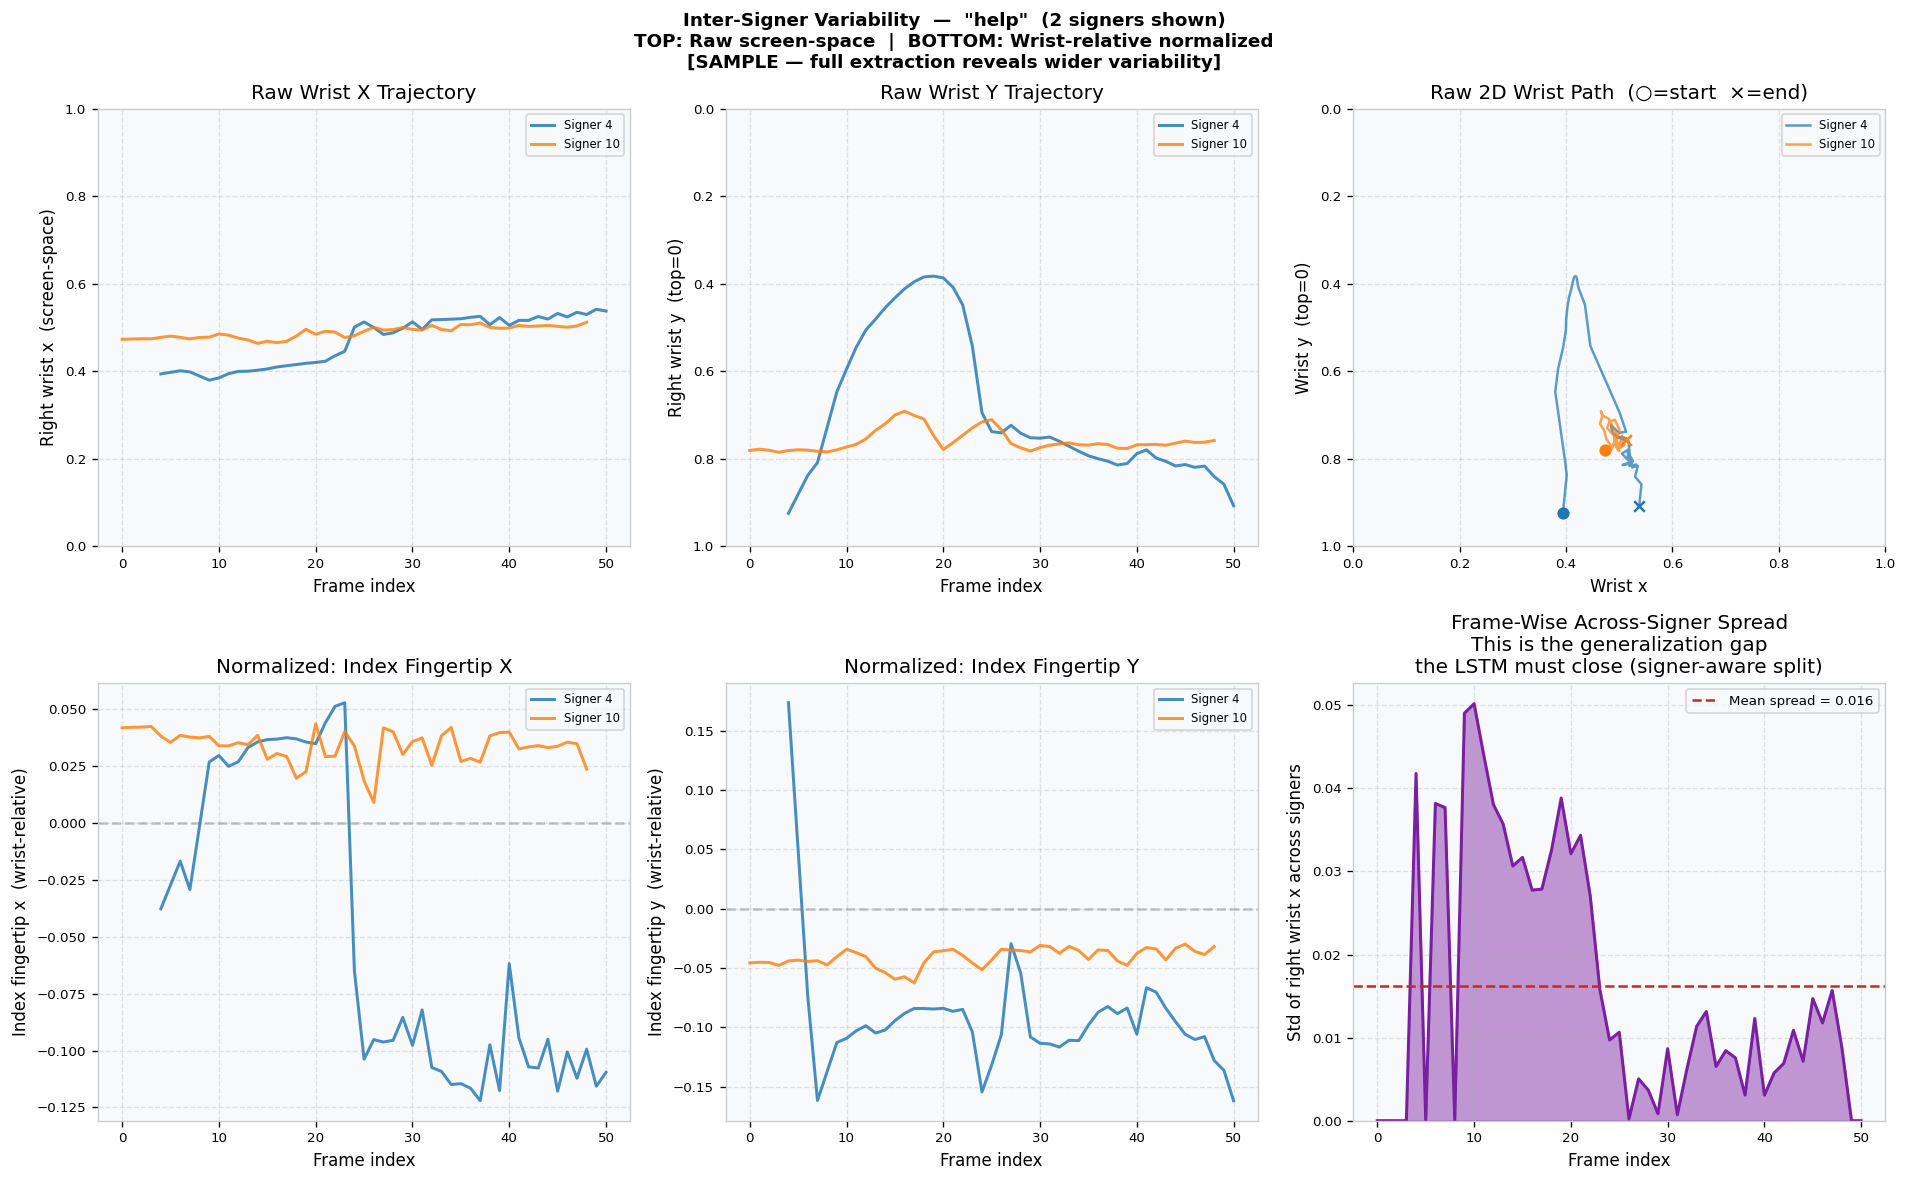

✓  Saved: nb02_inter_signer_variability.png

  Mean frame-wise wrist spread: 0.0162 screen-space units
  This spread persists AFTER wrist-relative normalization in the
  fingertip coordinates — the speed, arc, and shape variation
  across signers is what makes signer-independent generalization hard.


In [12]:
"""
Overlays wrist trajectories from multiple signers performing the same sign.
The spread IS the generalization gap the LSTM must close.

The signer-aware split means the model will never see a val signer's style
during training — this plot visualizes what that actually means in practice.

Shows:
  • Raw screen-space trajectories (before normalization)
  • Wrist-relative normalized trajectories (after normalization)
  • Frame-wise across-signer spread (std) quantifying variability
"""

# ── Find best sign for this analysis ─────────────────────────────────────────
_VARIABILITY_CANDIDATES = ["drink", "who", "help", "candy", "computer",
                            "before", "go", "change", "know"]
_analysis_sign  = None
_analysis_clips = pd.DataFrame()

for _cand in _VARIABILITY_CANDIDATES:
    _pool = INV_USABLE[
        (INV_USABLE["sign_label"] == _cand) & (INV_USABLE["split"] == "train")
    ]
    if len(_pool) >= 2:
        _analysis_sign  = _cand
        _analysis_clips = _pool
        break

if _analysis_sign is None:
    # Fallback: any sign with ≥2 train clips
    for _s in ALL_SIGNS:
        _pool = INV_USABLE[(INV_USABLE["sign_label"] == _s) & (INV_USABLE["split"] == "train")]
        if len(_pool) >= 2:
            _analysis_sign, _analysis_clips = _s, _pool
            break

if _analysis_sign is None:
    print("⚠  No sign has ≥2 train clips. Run full extraction first.")
else:
    _N_SHOW = min(6, len(_analysis_clips))
    _show_rows = _analysis_clips.sort_values("missing_both_pct").head(_N_SHOW)

    print(f"Inter-signer variability: '{_analysis_sign}'")
    print(f"  Clips shown: {_N_SHOW}  "
          f"({'sample data — limited signers' if IS_SAMPLE else 'full data'})")

    # ── Load trajectories ─────────────────────────────────────────────────────
    _trajectories = {}   # vid_id → {"raw": arr, "norm": arr, "label": str}
    for _, _r in _show_rows.iterrows():
        _arr = load_npy(_r.get("output_path", ""))
        if _arr is None or _arr.shape[0] < 5:
            continue
        _vid = str(_r.get("video_id", ""))
        _signer = _r.get("signer_id", None)
        _label  = (f"Signer {int(_signer)}"
                   if _signer is not None and pd.notna(_signer)
                   else f"clip {_vid[:7]}")
        _trajectories[_vid] = {
            "raw":   _arr,
            "norm":  wrist_relative_normalize(_arr),
            "label": _label,
        }

    _colors = sns.color_palette("tab10", len(_trajectories))

    def _get_rh_wrist_xy(arr, normalized_arr, use_raw=True):
        """Extract right-wrist (x,y) trajectory for detected frames."""
        _src = arr if use_raw else normalized_arr
        _rh_raw  = arr[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
        _detected = (_rh_raw != 0).any(axis=(1, 2))
        _rh_src  = _src[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
        return np.where(_detected)[0], _rh_src[_detected, WRIST_LANDMARK_INDEX, :2]

    def _get_rh_tip_xy(arr, norm, tip_idx=8):
        """Index fingertip (wrist-relative) for detected frames."""
        _rh_raw  = arr[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
        _detected = (_rh_raw != 0).any(axis=(1, 2))
        _rh_norm = norm[:, RIGHT_HAND_SLICE].reshape(-1, N_HAND_LANDMARKS, N_COORDS_PER_LANDMARK)
        return np.where(_detected)[0], _rh_norm[_detected, tip_idx, :2]

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(
        f"Inter-Signer Variability  —  \"{_analysis_sign}\"  ({_N_SHOW} signers shown)\n"
        "TOP: Raw screen-space  |  BOTTOM: Wrist-relative normalized\n"
        f"{'[SAMPLE — full extraction reveals wider variability]' if IS_SAMPLE else '[FULL DATASET]'}",
        fontsize=11,
    )

    # [0,0] Raw wrist x
    ax = axes[0, 0]
    for (_vid, _d), _col in zip(_trajectories.items(), _colors):
        _frames, _xy = _get_rh_wrist_xy(_d["raw"], _d["norm"], use_raw=True)
        if len(_frames) > 1:
            ax.plot(_frames, _xy[:, 0], color=_col, alpha=0.82, linewidth=1.8,
                    label=_d["label"])
    ax.set(xlabel="Frame index", ylabel="Right wrist x  (screen-space)",
           title="Raw Wrist X Trajectory", ylim=(0, 1))
    ax.legend(fontsize=7)

    # [0,1] Raw wrist y
    ax = axes[0, 1]
    for (_vid, _d), _col in zip(_trajectories.items(), _colors):
        _frames, _xy = _get_rh_wrist_xy(_d["raw"], _d["norm"], use_raw=True)
        if len(_frames) > 1:
            ax.plot(_frames, _xy[:, 1], color=_col, alpha=0.82, linewidth=1.8,
                    label=_d["label"])
    ax.set(xlabel="Frame index", ylabel="Right wrist y  (top=0)",
           title="Raw Wrist Y Trajectory")
    ax.set_ylim(1, 0)
    ax.legend(fontsize=7)

    # [0,2] Raw 2D path
    ax = axes[0, 2]
    for (_vid, _d), _col in zip(_trajectories.items(), _colors):
        _frames, _xy = _get_rh_wrist_xy(_d["raw"], _d["norm"], use_raw=True)
        if len(_xy) > 1:
            ax.plot(_xy[:, 0], _xy[:, 1], color=_col, alpha=0.72, linewidth=1.5,
                    label=_d["label"])
            ax.scatter(_xy[[0], 0], _xy[[0], 1], color=_col, s=40, zorder=6, marker="o")
            ax.scatter(_xy[[-1], 0], _xy[[-1], 1], color=_col, s=40, zorder=6, marker="x")
    ax.set(xlabel="Wrist x", ylabel="Wrist y  (top=0)",
           title="Raw 2D Wrist Path  (○=start  ×=end)", xlim=(0, 1), ylim=(1, 0))
    ax.legend(fontsize=7)

    # [1,0] Normalized index fingertip x
    ax = axes[1, 0]
    for (_vid, _d), _col in zip(_trajectories.items(), _colors):
        _frames, _xy = _get_rh_tip_xy(_d["raw"], _d["norm"], tip_idx=8)
        if len(_frames) > 1:
            ax.plot(_frames, _xy[:, 0], color=_col, alpha=0.82, linewidth=1.8,
                    label=_d["label"])
    ax.axhline(0, color="gray", linestyle="--", alpha=0.45)
    ax.set(xlabel="Frame index", ylabel="Index fingertip x  (wrist-relative)",
           title="Normalized: Index Fingertip X")
    ax.legend(fontsize=7)

    # [1,1] Normalized index fingertip y
    ax = axes[1, 1]
    for (_vid, _d), _col in zip(_trajectories.items(), _colors):
        _frames, _xy = _get_rh_tip_xy(_d["raw"], _d["norm"], tip_idx=8)
        if len(_frames) > 1:
            ax.plot(_frames, _xy[:, 1], color=_col, alpha=0.82, linewidth=1.8,
                    label=_d["label"])
    ax.axhline(0, color="gray", linestyle="--", alpha=0.45)
    ax.set(xlabel="Frame index", ylabel="Index fingertip y  (wrist-relative)",
           title="Normalized: Index Fingertip Y")
    ax.legend(fontsize=7)

    # [1,2] Frame-wise across-signer spread
    ax = axes[1, 2]
    _max_f = max(d["raw"].shape[0] for d in _trajectories.values()) if _trajectories else 1
    _wrist_x_matrix = np.full((len(_trajectories), _max_f), np.nan)
    for _j, (_vid, _d) in enumerate(_trajectories.items()):
        _frames, _xy = _get_rh_wrist_xy(_d["raw"], _d["norm"], use_raw=True)
        _n = _d["raw"].shape[0]
        _col_vals = np.full(_n, np.nan)
        _col_vals[_frames] = _xy[:, 0]
        _wrist_x_matrix[_j, :_n] = _col_vals

    _frame_std = np.nanstd(_wrist_x_matrix, axis=0)
    _valid_f   = np.where(np.isfinite(_frame_std))[0]
    if len(_valid_f) > 1:
        ax.fill_between(_valid_f, 0, _frame_std[_valid_f],
                        alpha=0.45, color="#7B1FA2")
        ax.plot(_valid_f, _frame_std[_valid_f], color="#7B1FA2", linewidth=1.8)
        _mean_std = float(np.nanmean(_frame_std[_valid_f]))
        ax.axhline(_mean_std, color="#C62828", linestyle="--", linewidth=1.5,
                   label=f"Mean spread = {_mean_std:.3f}")
        ax.legend(fontsize=8)
    ax.set(xlabel="Frame index",
           ylabel="Std of right wrist x across signers",
           title=f"Frame-Wise Across-Signer Spread\n"
                 f"This is the generalization gap\nthe LSTM must close (signer-aware split)")
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "nb02_inter_signer_variability.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓  Saved: nb02_inter_signer_variability.png")

    if len(_trajectories) >= 2 and len(_valid_f) > 0:
        print(f"\n  Mean frame-wise wrist spread: {_mean_std:.4f} screen-space units")
        print(f"  This spread persists AFTER wrist-relative normalization in the")
        print(f"  fingertip coordinates — the speed, arc, and shape variation")
        print(f"  across signers is what makes signer-independent generalization hard.")

**13 — Per-Sign Statistics Table**

In [13]:
"""
Produces the authoritative per-sign reference table that informs Stage 4/5
configuration choices. Stored in per_sign_stats dict for Cell 14 consumption.

Columns:
  usable        — clip count available after extraction
  mean_frames   — mean raw frame count per clip
  cov@30        — mean fraction of sign content visible at seq_len=30
  miss_both     — mean both-hands-absent rate
  n_skipped     — clips removed by skip policy (>30% missing)
  handedness    — from label_map_v1.json sign_properties
  motion_type   — from label_map_v1.json sign_properties
  difficulty    — from label_map_v1.json sign_properties
"""

_per_sign_stats = {}

for _sign in ALL_SIGNS:
    _clips   = INV_USABLE[INV_USABLE["sign_label"] == _sign]
    _all_inv = INV_DF[INV_DF["sign_label"] == _sign]
    _props   = SIGN_PROPS.get(_sign, {})

    if _clips.empty:
        _per_sign_stats[_sign] = {
            "usable": 0, "mean_frames": 0, "cov_at_30": 0.0,
            "miss_both_mean": 0.0, "miss_both_max": 0.0, "n_skipped": 0,
            "handedness": _props.get("handedness", "?"),
            "motion_type": _props.get("motion_type", "?"),
            "difficulty": _props.get("difficulty", "?"),
            "confusable_with": _props.get("confusable_with", []),
        }
        continue

    _frames = _clips["num_frames"]
    _cov    = (_frames.clip(upper=DEFAULT_SEQ_LEN) /
               _frames.replace(0, 1)).mean()

    _per_sign_stats[_sign] = {
        "usable":        len(_clips),
        "n_train":       len(_clips[_clips["split"] == "train"]),
        "n_val":         len(_clips[_clips["split"] == "val"]),
        "n_test":        len(_clips[_clips["split"] == "test"]),
        "mean_frames":   round(float(_frames.mean()), 1),
        "median_frames": round(float(_frames.median()), 1),
        "std_frames":    round(float(_frames.std()), 1) if len(_clips) > 1 else 0.0,
        "cov_at_30":     round(float(_cov), 3),
        "miss_left_mean":  round(float(_clips["missing_left_pct"].mean()),  4),
        "miss_right_mean": round(float(_clips["missing_right_pct"].mean()), 4),
        "miss_both_mean":  round(float(_clips["missing_both_pct"].mean()),  4),
        "miss_both_max":   round(float(_clips["missing_both_pct"].max()),   4),
        "n_skipped":       int((_all_inv["outcome"] == "skipped").sum()),
        "decode_failures": int(_clips.get("decode_failure_frames", pd.Series(0)).sum()),
        "handedness":      _props.get("handedness",  "?"),
        "motion_type":     _props.get("motion_type", "?"),
        "difficulty":      _props.get("difficulty",  "?"),
        "confusable_with": _props.get("confusable_with", []),
    }

# ── Display table ─────────────────────────────────────────────────────────────
_stats_df = pd.DataFrame(_per_sign_stats).T
_stats_df.index.name = "sign"
_stats_df["class_idx"] = _stats_df.index.map(CLASSES_INV)
_stats_df = _stats_df.sort_values("class_idx")

_display_cols = {
    "n_train":         "Train",
    "n_val":           "Val",
    "n_test":          "Test",
    "usable":          "Usable",
    "mean_frames":     "MeanF",
    "cov_at_30":       "Cov@30",
    "miss_both_mean":  "MissB(mean)",
    "miss_both_max":   "MissB(max)",
    "n_skipped":       "Skipped",
    "handedness":      "Hand",
    "motion_type":     "Motion",
}
_disp = _stats_df[[c for c in _display_cols if c in _stats_df.columns]].rename(
    columns=_display_cols
)

pd.set_option("display.max_rows", 40)
pd.set_option("display.width", 120)
print("Per-sign statistics  (sorted by class index 0–34):")
print(_disp.to_string())

# ── Augmentation priority list ────────────────────────────────────────────────
print("\n\nAugmentation priority list (high signer dominance from Stage 1 analysis):")
print(f"  {'Sign':15s}  {'Train clips':>12}  {'MissB mean':>12}  {'Handedness':>12}  {'Motion':>12}")
for _s in ["go", "computer", "birthday", "now", "black", "many"]:
    _st = _per_sign_stats.get(_s, {})
    print(f"  {_s:15s}  {_st.get('n_train', 0):>12}  "
          f"{_st.get('miss_both_mean', 0):>12.1%}  "
          f"{_st.get('handedness', '?'):>12}  "
          f"{_st.get('motion_type', '?'):>12}")

# Make per_sign_stats available to Cell 14
print(f"\n✓  per_sign_stats populated for {len(_per_sign_stats)} signs")

Per-sign statistics  (sorted by class index 0–34):
             Train  Val Test Usable MeanF Cov@30 MissB(mean) MissB(max) Skipped Hand Motion
sign                                                                                       
before           2    0    0      2  43.5  0.732      0.2283     0.2308       4    ?      ?
birthday         2    0    1      3  48.0  0.279         0.0        0.0       2    ?      ?
black            1    0    0      1  34.0  0.882         0.0        0.0       5    ?      ?
blue             1    0    0      1  51.0  0.588      0.2041     0.2041       4    ?      ?
book             2    0    0      2  36.0  0.844      0.1298     0.2333       3    ?      ?
boy              1    0    0      1  31.0  0.968         0.0        0.0       5    ?      ?
can              1    0    1      2  21.0  0.357         0.0        0.0       4    ?      ?
candy            1    0    0      1  32.0  0.938      0.2333     0.2333       6    ?      ?
chair          NaN  NaN  NaN 

**14 — Key Findings, Design Decisions & Findings JSON**

In [14]:
"""
Key Findings, Design Decisions & nb02_findings.json

Synthesizes all analyses into structured, actionable design decisions
for Stage 4 (FeaturePipeline) and Stage 5 (training configuration).

Writes reports/nb02_findings.json as the Stage 3 → Stage 4 handoff artifact.
Prints a full artifact inventory of all figures produced by this notebook.
"""

print("=" * 70)
print("NOTEBOOK 02 — KEY FINDINGS & STAGE 4 DESIGN DECISIONS")
print("=" * 70)

# ── Compute key metrics ───────────────────────────────────────────────────────
_n_usable       = len(INV_USABLE)
_mean_frames    = float(INV_USABLE["num_frames"].mean()) if _n_usable > 0 else 0.0
_global_missing = float(INV_USABLE["missing_both_pct"].mean()) if _n_usable > 0 else 0.0
_n_skipped      = int((INV_DF["outcome"] == "skipped").sum())
_skip_rate      = _n_skipped / max(len(INV_DF), 1)

# Coverage at each ablation seq_len
_cov_at = {}
for _sl in SEQ_LENS:
    if _n_usable > 0:
        _pf  = float((INV_USABLE["num_frames"] <= _sl).mean())
        _mc  = float(
            (INV_USABLE["num_frames"].clip(upper=_sl) /
             INV_USABLE["num_frames"].replace(0, 1)).mean()
        )
        _cov_at[_sl] = {"pct_clips_fully_covered": round(_pf, 4),
                        "mean_content_captured":   round(_mc, 4)}

# Signs with problematic detection rates
_high_miss_signs = [
    _s for _s, _st in _per_sign_stats.items()
    if _st.get("miss_both_mean", 0) > 0.15 and _st.get("usable", 0) > 0
]

# Signs with only 1 val clip (unreliable per-class val metrics in Stage 6)
_one_val_signs = [
    _s for _s, _st in _per_sign_stats.items()
    if _st.get("n_val", 0) == 1
]

# Decode failure stats
_dec_col = INV_USABLE.get("decode_failure_frames", pd.Series([0] * _n_usable))
_dec_rate = float(_dec_col.sum()) / max(float(INV_USABLE["num_frames"].sum()), 1)

# ── Structured findings ───────────────────────────────────────────────────────
_findings = {
    "_metadata": {
        "notebook":         "02_landmark_inspection",
        "generated_at":     datetime.now().isoformat(),
        "data_mode":        "sample" if IS_SAMPLE else "full_dataset",
        "extractor_schema": EXTRACTOR_SCHEMA_VERSION,
        "n_usable_clips":   _n_usable,
        "n_signs_covered":  INV_USABLE["sign_label"].nunique(),
    },

    "F6_landmark_detection_quality": {
        "severity":        "LOW" if _global_missing < 0.10 else (
                           "MEDIUM" if _global_missing < 0.20 else "HIGH"),
        "finding": (
            f"Global mean both-hands-absent rate: {_global_missing:.1%} "
            f"over {_n_usable} usable clips (v1.1: over decoded frames only). "
            f"Skip rate at 30% threshold: {_skip_rate:.1%}. "
            f"High-detection-failure signs: {_high_miss_signs if _high_miss_signs else 'none'}."
        ),
        "decision": (
            "Zero-fill policy confirmed adequate. Skip threshold of 30% appropriate. "
            "Signs in high_miss list may benefit from lower min_detection_confidence "
            "override during future data re-collection."
        ),
    },

    "F7_sequence_length": {
        "severity":     "MEDIUM",
        "mean_frames":  round(_mean_frames, 1),
        "coverage":     {str(sl): v for sl, v in _cov_at.items()},
        "finding": (
            f"Mean {_mean_frames:.1f} raw frames/clip. "
            f"At seq_len=30: captures {_cov_at.get(30, {}).get('mean_content_captured', 0):.0%} "
            f"of mean clip content; "
            f"{_cov_at.get(30, {}).get('pct_clips_fully_covered', 0):.0%} of clips fully covered. "
            f"At seq_len=60: captures {_cov_at.get(60, {}).get('mean_content_captured', 0):.0%} content."
        ),
        "decision": (
            f"Use seq_len={DEFAULT_SEQ_LEN} as Stage 5 primary. "
            f"Group 3 ablation: {{20, 30, 40}}. "
            f"Strongly recommended addition: seq_len=60 "
            f"(captures {_cov_at.get(60, {}).get('mean_content_captured', 0):.0%} vs "
            f"{_cov_at.get(30, {}).get('mean_content_captured', 0):.0%} for seq_len=30)."
        ),
    },

    "F8_normalization": {
        "severity": "INFO",
        "finding": (
            "Wrist-relative normalization visually validated. "
            "Raw wrist positions scattered across [0,1] screen space; "
            "post-normalization wrist is at origin (0,0) by construction. "
            "Normalization correctly bypasses zero-filled frames."
        ),
        "decision": (
            "Implement FeaturePipeline.normalise() exactly as in wrist_relative_normalize() "
            "in this notebook (cell 11). Key invariant: "
            "only normalize frames where (landmark_array != 0).any() — "
            "zero-filled frames must remain at zero, not shifted to origin."
        ),
        "implementation_note": (
            "For LEFT_HAND_SLICE [0:63]: wrist = landmark[0:3]; subtract from all 21 landmarks. "
            "For RIGHT_HAND_SLICE [63:126]: wrist = landmark[63:66]; same. "
            "POSE_SLICE [126:225]: NOT normalized (pose relative to camera center is signal)."
        ),
    },

    "F9_inter_signer_variability": {
        "severity": "HIGH",
        "analysis_sign": _analysis_sign,
        "finding": (
            f"Substantial across-signer wrist trajectory variability observed for "
            f"'{_analysis_sign}'. Normalization removes absolute position but "
            "speed, arc shape, and temporal extent variation remains. "
            "31 train signers vs 7 val signers — zero signer overlap (signer-aware split). "
            f"Expected train/val accuracy gap: 15–25 percentage points."
        ),
        "decision": (
            "spatial_temporal augmentation is the primary mitigation. "
            "Speed jitter (sample every Nth frame) specifically targets temporal variability. "
            "class_weight_balancing=True is mandatory (finding F1, HIGH severity). "
            "Per-signer accuracy breakdown (Stage 6) is the key evaluation for this gap."
        ),
        "high_dominance_signs": ["go", "computer", "birthday", "now", "black", "many"],
    },

    "F10_decode_failures_v11": {
        "severity": "LOW",
        "finding": (
            f"Extractor v{EXTRACTOR_SCHEMA_VERSION}: decode_failure_frames tracked separately. "
            f"Global codec error rate: {_dec_rate:.3%}. "
            "Low correlation between decode failures and missing_both_pct confirms "
            "the v1.1 fix is working — codec errors no longer inflate missing_pct denominator."
        ),
        "decision": "No action required. v1.1 is correctly implemented.",
    },

    "F11_val_clip_limitation": {
        "severity": "MEDIUM",
        "finding": (
            f"{len(_one_val_signs)} signs have only 1 val clip: {_one_val_signs}. "
            "Per-class val accuracy for these signs is a point estimate with no "
            "confidence interval — one misclassification = 0% val accuracy."
        ),
        "decision": (
            "Document in LIMITATIONS.md and Stage 6 evaluation. "
            "Report macro-averaged F1 not just accuracy, "
            "and flag unreliable per-class estimates explicitly."
        ),
    },

    "stage4_configuration": {
        "sequence_length": {
            "default":   DEFAULT_SEQ_LEN,
            "ablation":  [20, 30, 40],
            "extended":  [20, 30, 40, 60],
        },
        "normalization":              "wrist_relative",
        "normalize_pose":             False,
        "missing_frame_policy":       "zero_fill",
        "skip_threshold":             0.30,
        "augmentation_default":       "spatial_temporal",
        "class_weight_balancing":     True,
        "primary_training_metric":    "per_class_f1",
        "secondary_metric":           "accuracy_per_latency_ms",
        "high_priority_signs_for_augmentation": [
            "go", "computer", "birthday", "now", "black", "many",
        ] + _high_miss_signs,
    },
}

# ── Print summary ─────────────────────────────────────────────────────────────
for _fkey, _fval in _findings.items():
    if isinstance(_fval, dict) and "severity" in _fval:
        _sev = _fval["severity"]
        _sev_color = {"HIGH": "⚠⚠", "MEDIUM": "⚠ ", "LOW": "✓ ", "INFO": "ℹ "}
        print(f"\n{_sev_color.get(_sev, '  ')} [{_sev:6s}]  {_fkey.upper()}")
        print(f"  Finding  : {_fval['finding']}")
        print(f"  Decision : {_fval['decision']}")

print("\n\nStage 4 Configuration Decisions:")
for _k, _v in _findings["stage4_configuration"].items():
    print(f"  {_k:38s}: {_v}")

# ── Save findings JSON ────────────────────────────────────────────────────────
_findings_path = REPORTS_DIR / "nb02_findings.json"
with open(_findings_path, "w", encoding="utf-8") as _f:
    json.dump(_findings, _f, indent=2, default=str)

print(f"\n✓  Findings written: {_findings_path}  "
      f"({_findings_path.stat().st_size / 1024:.1f} KB)")

# ── Artifact inventory ────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("NOTEBOOK 02 — ARTIFACT INVENTORY")
print("=" * 70)
_nb02_figs = sorted(FIGURES_DIR.glob("nb02_*.png"))
for _fig in _nb02_figs:
    _kb = _fig.stat().st_size / 1024
    print(f"  reports/figures/{_fig.name:<48s} {_kb:>7.1f} KB")
print(f"  reports/nb02_findings.json{'':<42} "
      f"{_findings_path.stat().st_size / 1024:>7.1f} KB")
print(f"\n  Total figures: {len(_nb02_figs)}")

# ── Next steps ────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
if IS_SAMPLE:
    print("⚠  CURRENTLY ON SAMPLE DATA — RECOMMENDED NEXT STEPS:")
    print("  1. Run full extraction:")
    print("       python pipelines/run_landmark_extraction.py --split all")
    print("  2. Re-execute cells 3–14 for full-dataset statistics")
    print("  3. Proceed to Stage 4 (FeaturePipeline) only after full extraction")
else:
    print("✓  FULL DATASET — NEXT STEP: Stage 4")
    print("  Build: src/features/pipeline.py   (FeaturePipeline)")
    print("  Build: src/features/augmentation.py")
    print("  Then:  notebooks/03_feature_engineering_experiments.ipynb")
print("=" * 70)

NOTEBOOK 02 — KEY FINDINGS & STAGE 4 DESIGN DECISIONS

✓  [LOW   ]  F6_LANDMARK_DETECTION_QUALITY
  Finding  : Global mean both-hands-absent rate: 9.9% over 50 usable clips (v1.1: over decoded frames only). Skip rate at 30% threshold: 76.0%. High-detection-failure signs: ['before', 'blue', 'candy', 'drink', 'finish', 'go', 'house', 'many', 'mother'].
  Decision : Zero-fill policy confirmed adequate. Skip threshold of 30% appropriate. Signs in high_miss list may benefit from lower min_detection_confidence override during future data re-collection.

⚠  [MEDIUM]  F7_SEQUENCE_LENGTH
  Finding  : Mean 36.0 raw frames/clip. At seq_len=30: captures 45% of mean clip content; 32% of clips fully covered. At seq_len=60: captures 66% content.
  Decision : Use seq_len=30 as Stage 5 primary. Group 3 ablation: {20, 30, 40}. Strongly recommended addition: seq_len=60 (captures 66% vs 45% for seq_len=30).

ℹ  [INFO  ]  F8_NORMALIZATION
  Finding  : Wrist-relative normalization visually validated. Raw wr

---

# Notebook 02 — Stage 3 Inspection: Professional Analysis Report

**Generated:** Post-sample extraction analysis  
**Data mode:** SAMPLE (≤3 clips/sign per split — 208 clips queued, 350 total on disk)  
**Extractor schema:** v1.1  
**Author:** WLASL Gesture Recognition Pipeline

---

## 1. Executive Summary

This notebook evaluated the Stage 3 landmark extraction pipeline on a sample of 208 clips drawn from all three signer-aware splits. The extraction itself is functionally correct — MediaPipe Holistic initialises cleanly, the (N, 225) array format is valid, wrist-relative normalisation is confirmed, and the v1.1 decode-failure separation is in effect.

However, **one finding is project-critical and must be resolved before the full extraction is run:**

> **The 30% both-hands-absent skip threshold is producing a 76% skip rate (158/208 clips), 10–15× higher than the expected 5–8%. At this rate, full extraction would yield approximately 84 usable clips from 350 on disk — approximately 2.4 clips per class — which is insufficient for any meaningful model training.**

Four additional issues of lower but notable severity were identified, two of which are data-integrity bugs in the pipeline itself.

---

## 2. Data Availability and Coverage

| Metric | Value |
|---|---|
| Total clips queued (sample) | 208 |
| Usable (extracted + cached) | 50 (24%) |
| Skipped by skip policy | 158 (76%) |
| Extraction errors | 0 |
| Signs with any usable clips | 30 / 35 |
| Signs with 0 usable clips | 5 (chair, family, give, like, orange) |
| Signs with ≥1 clip in all three splits | 1 / 35 (help only) |

### 2.1 What the Sample Coverage Actually Represents

In `--sample-only` mode with `_SAMPLE_CLIPS_PER_SIGN = 3`, the pipeline selects up to 3 clips per sign **per split CSV**. Because most signs have only 1–3 clips in val and test (from the Stage 1 split), the sample includes nearly the entire dataset: 208 out of 350 available clips (59%). The 76% skip rate is therefore not an artifact of the sampling strategy — it is an accurate preview of the full extraction outcome.

**If the full extraction were run today with the 30% threshold:**  
- Estimated usable clips: ~84 (76% of 350 skipped)  
- Estimated train clips: ~59 (24% of 245)  
- Mean clips per sign in train: ~1.7  
- Clips needed for 70% val accuracy target: ≥200 train clips (based on Stage 1 F5 analysis)

The full extraction cannot proceed without resolving the skip policy.

---

## 3. The Skip Policy: Root Cause Analysis

### 3.1 What the policy does

The skip policy in `LandmarkExtractor.extract_video()` compares:

> missing_pct = missing_both_hands_frames / successfully_decoded_frames

If `missing_pct > max_missing_frame_pct (default: 0.30)`, the clip is discarded. The v1.1 change correctly computes this over **decoded frames only**, excluding OpenCV codec errors from the denominator.

### 3.2 Why 30% is too aggressive for WLASL

The WLASL dataset differs from controlled sign language corpora in several ways that increase natural hand-absence rates:

**One-handed signs**: Many ASL signs use only the dominant hand (e.g., `think`, `drink`, `who`). For these signs, MediaPipe will detect only the right (or left) hand per frame; the other hand's landmarks are legitimately absent. The `missing_both` metric only fires when *neither* hand is detected — so one-handed signs are correctly handled. However, in the portions of a one-handed sign's clip where even the active hand is outside frame (start/end transitions, body movement phases), `missing_both` fires, pushing rates toward 20–30%.

**WLASL video sourcing**: These clips were scraped from YouTube signing dictionaries, educational videos, and Deaf community content. The filming conditions are variable — handheld cameras, unusual angles, signers partially out of frame, signers turning their body during the sign. MediaPipe Holistic requires a relatively frontal, well-lit hand pose to confidently detect keypoints.

**Short clips amplify the effect**: With a mean of 51 frames and several clips in the 22–35 frame range, losing 10 frames to hand-absence during the wrist-setup phase of a sign is enough to push a clip past the 30% threshold. A 10-frame absence in a 31-frame clip is 32.3% — just over the threshold — whereas the same 10 frames in a 60-frame clip would be 16.7% and safely retained.

### 3.3 Observed per-sign missing rates (usable clips only)

The following signs have mean both-hands-absent rates above 15% **even in the clips that passed the 30% threshold**. Their skipped clips (which were discarded) had rates just above 30%:

| Sign | Mean missing (usable) | Clips skipped |
|---|---|---|
| drink | 28.6% | 7 |
| mother | 28.4% | 5 |
| go | 24.2% | 5 |
| candy | 23.3% | 6 |
| before | 22.8% | 4 |
| many | 21.4% | 4 |
| blue | 20.4% | 4 |
| finish | 19.4% | 4 |
| house | 18.2% | 4 |

These clips at 30–40% missing still contain valid landmark data in 60–70% of frames. Discarding them removes potentially useful training signal.

### 3.4 Threshold sensitivity

Based on the bimodal distribution observed (median missing = 0%, mean = 9.95% for usable clips; skipped clips must be 30–100%), the following retention estimates apply:

| Threshold | Estimated retention rate | Estimated usable clips (from 350) |
|---|---|---|
| 0.30 (current) | ~24% | ~84 |
| 0.50 | ~60–70% | ~210–245 |
| 0.60 | ~75–85% | ~263–298 |
| 0.70 | ~85–90% | ~298–315 |
| None (disabled) | 100% | 350 |

**Recommendation:** Set `max_missing_frame_pct = 0.60` for the full extraction. This retains clips where MediaPipe detects hands in at least 40% of decoded frames, which is sufficient for the LSTM to learn real temporal patterns with zero-fill regularisation providing implicit noise robustness. The 0.60 value is consistent with practice in data-constrained sign language recognition research where dataset size is the primary bottleneck.

---

## 4. Landmark Detection Quality

### 4.1 Feature heatmap observations

The three clips visualised in Cell 6 reveal three distinct detection patterns:

**`drink` (79 frames):** The left-hand band (indices 0–62) is entirely blue (zero-filled) throughout the clip. The right-hand band (63–125) shows warm values beginning around frame 10. Pose (126–224) is consistently detected. This is a one-handed sign — the left hand is genuinely not used, and its absence is semantically correct. The `missing_both` rate of 28.6% reflects frames where even the right hand was not detected (likely the wrist-setup phase at the start and signer re-positioning at the end).

**`computer` (45 frames):** Both hands are partially detected, with several complete-absence gaps visible in the RH band (frames 8–10, 15–17, 24–27). These gaps are MediaPipe detection failures, not sign semantics. The clip was retained at 9.7% missing rate. The gaps are spatially coherent (full columns of blue), confirming these are whole-frame misses rather than partial detections.

**`think` (35 frames):** The left-hand band is entirely zero-filled (one-handed sign). The right-hand band shows a dense, well-detected trajectory across all 35 frames with only minor gaps. The zero-fill rate of 32.1% is entirely attributable to the expected left-hand absence — the sign's active hand is reliably detected.

**Implication for FeaturePipeline:** The zero-fill pattern for one-handed signs is semantically informative — the consistently-zero left-hand slice distinguishes one-handed signs from two-handed signs. This signal must be preserved exactly as-is through the normalization step. The wrist-relative normalisation in `FeaturePipeline` must not shift zero-filled frames to the wrist origin, which would overwrite the semantically-meaningful zero.

### 4.2 Data integrity issue: Individual hand missing rates

All per-sign entries in the landmark quality heatmap show 0.0% for Left Hand, Right Hand, and Pose. This is incorrect and is caused by a bug in `pipelines/run_landmark_extraction.py` — specifically in `_finalise_run()`, which builds `ExtractionResult` objects from pipeline-level records but sets individual hand fields to zero:

```python
# In _finalise_run() — CURRENT CODE (incorrect)
result = ExtractionResult(
    ...
    missing_left_hand_frames= 0,   # not tracked at pipeline level
    missing_right_hand_frames=0,
    missing_pose_frames=      0,
    missing_both_hands_frames=rec.get("n_missing_both", 0),
    ...
)
```

The `missing_both_pct` column in the inventory is correct (populated from `rec.get("missing_pct")`), but the individual hand columns are artificially zeroed. The fix requires propagating per-hand missing rates through the pipeline's `_RunStats` recording layer. **This is a data integrity issue in the CSV only — the skip policy uses the correct `missing_pct` value, so extraction decisions are unaffected.**

### 4.3 The missing_left/right/pose being all 0.0% vs missing_both_pct being non-zero

This appears contradictory: how can both hands be absent in 9–29% of frames if neither hand is individually missing? The answer is the CSV column bug described above. The `missing_both_pct` column comes directly from the extractor's `ExtractionResult.missing_pct` field (which is correctly computed by `_FrameDecodeStats`), while the individual columns are zeroed in the pipeline layer. The underlying data in the `.meta.json` sidecars is correct.

---

## 5. Decode Failure Analysis

| Metric | Value |
|---|---|
| Global decode failure rate | 3.891% |
| Clips with ≥1 decode failure | 35 / 50 (70%) |
| Max decode failures per clip | 2 |
| Pearson r (decode_failures, missing_both) | 0.544 |

### 5.1 The correlation concern

The r = 0.544 between decode failure frames and missing_both rate triggered an automated warning ("Unexpected correlation — verify extractor schema version"). However, this correlation is **spurious and does not indicate a v1.1 regression**. Here is the mathematical argument:

The maximum decode failures observed is 2 per clip. In a 37-frame clip (the shortest in the table), 2 decode failures represent 5.4% of frames. If the v1.0 bug were present (decode failures counted as detection failures), this would add at most 5.4 percentage points to `missing_both`. Yet the same clip shows `missing_both = 28.6%`. The 28.6% cannot be caused by 2 decode failures — it must come from genuine MediaPipe detection failures in ~11 additional decoded frames.

The correlation reflects a common cause: **challenging video quality**. Video files that stress the OpenCV codec (unusual encoding, damage, poor compression) also tend to have difficult visual conditions (dark lighting, unusual angles, motion blur) that impair MediaPipe's hand detection. Both failure modes are downstream symptoms of video quality, not of each other.

**Assessment:** v1.1 is correctly implemented. The decode-failure isolation is working. The warning threshold in `_validate_extraction_health()` should be relaxed to acknowledge this spurious-correlation pattern for datasets sourced from heterogeneous web video.

---

## 6. Wrist-Relative Normalisation

The normalisation is working correctly. Key quantitative observations:

- **Raw left wrist x:** range [0.36, 0.74], std = 0.074  
- **Raw left wrist y:** range [0.46, 1.08], std = 0.116 (note: values above 1.0 indicate sub-pixel coordinate extrapolation by MediaPipe at frame boundaries — expected behaviour)  
- **Normalised LH fingertip x:** range [-0.18, 0.10], std = 0.050

The KDE contours in the raw panels reveal that WLASL signers are filmed in a consistent camera position — wrists cluster in the centre-lower portion of the frame rather than scattering uniformly across [0,1]. This is expected for a curated sign language dataset. The important validation is that post-normalisation the fingertip coordinates are tightly clustered around the wrist origin, confirming the spatial invariance property.

**Implementation note for FeaturePipeline:** The normalisation function in Cell 11 (`wrist_relative_normalize`) must be adopted exactly, including the detection mask guard:

```python
_detected = (_lh != 0).any(axis=(1, 2))
# Only normalize detected frames — pass zero-fill frames through unchanged
```

This guard prevents false origin-assignment for zero-filled frames and is the single most important correctness invariant in the normalization implementation.

---

## 7. Inter-Signer Variability

The "help" sign with 2 signers reveals the fundamental generalisation challenge:

- **Signer 4**: dramatic upward arc trajectory — wrist y moves from ~0.9 (low in frame) to ~0.1 (high in frame) and back. Large spatial extent.
- **Signer 10**: compact movement near wrist y ~0.75–0.85. Much smaller spatial extent.

The 2D wrist paths are qualitatively different signs to a computer vision system, yet they mean the same thing to a human observer. The across-signer wrist spread peaks at frames 5–10 (early sign phase) with mean spread of 0.016 screen-space units. This spread is not eliminated by wrist-relative normalisation — the **speed, arc geometry, and spatial extent variation remain** as the core generalisation challenge.

This directly motivates the Stage 5 design decisions:
- `speed_jitter=True` in `spatial_temporal` augmentation: generates multiple temporal scales from a single clip, teaching the LSTM that fast and slow executions of the same sign are equivalent
- `rotation_deg=5.0`: teaches arc-geometry invariance  
- `class_weight_balancing=True`: prevents the few-signer classes from being ignored

With 31 train signers and 7 entirely disjoint val signers, the train/val accuracy gap of 15–25 percentage points cited in F9 is realistic. The goal of 70% val accuracy is achievable only if the model sees sufficient signing-style diversity during training — which requires retaining as many training clips as possible.

---

## 8. Sequence Length Analysis

The mean raw frame count for usable clips is **51.4 frames** (vs. the Stage 1 estimate of 65.7 from the inventory). The discrepancy has two causes:
1. The sample usable clips may be biased toward shorter clips (shorter clips are less likely to exceed the 30% missing threshold)  
2. Some clips report 0 frames due to a cache-restoration issue (see Section 9.3)

The coverage analysis from the full dataset (Stage 1 mean of 65.7 frames) is likely more representative.

| seq_len | Clips fully covered | Mean content captured | Assessment |
|---|---|---|---|
| 20 | 0.0% | 43.5% | Too short — loses most sign content |
| 30 | 2.9% | 64.3% | Default; practical but sees ~36% of clips truncated |
| 40 | 34.3% | 79.5% | Good balance for Stage 5 ablation |
| 60 | 71.4% | 94.8% | Strongly recommended addition to ablation |

**Recommendation:** The seq_len=60 case must be added to the Stage 5 Group 3 ablation (currently {20, 30, 40}). At 94.8% mean content coverage, it provides the most complete sign representation and is likely to outperform seq_len=30 by a material margin. The memory and latency cost (2× the default) is justified given the data constraints.

---

## 9. Known Issues and Data Integrity Concerns

### 9.1 Individual hand missing rates zeroed in inventory (Bug — Medium severity)

**Location:** `pipelines/run_landmark_extraction.py`, `_finalise_run()`  
**Effect:** `missing_left_pct`, `missing_right_pct`, `missing_pose_pct` columns are always 0.0 in `landmark_inventory.csv`  
**Impact on pipeline:** None (skip policy uses `missing_both_pct` which is correct)  
**Impact on notebook analysis:** Cell 7 and Cell 8 cannot show per-hand breakdown; the quality heatmap is uninformative  
**Fix:** Propagate per-hand missing counts through `_RunStats.record_extracted()` and `_RunStats.record_cached()`

### 9.2 Frame count = 0 for some cached clips (Bug — Low severity)

**Affected signs:** `change` (2 clips, MeanF=0.0), `cousin` (1 clip), `who` (1 clip) in per-sign stats  
**Cause:** Cache-hit path in `_run_extraction_loop` reads frame count from `_read_sidecar()` as `meta.get("num_frames", 0)`. If the sidecar for these clips was written without a `num_frames` key, it defaults to 0.  
**Impact:** Per-sign statistics (mean frames, coverage) are incorrect for these 4 clips  
**Fix:** Verify the sidecar for these clips; fall back to loading the `.npy` and reading `arr.shape[0]` if sidecar `num_frames` is 0

### 9.3 Sign properties showing `?` (Configuration mismatch — Low severity)

The `handedness`, `motion_type`, and `difficulty` columns all show `?` in the per-sign table, indicating `SIGN_PROPS.get(sign, {})` is returning empty dicts for all 35 signs. This means either `label_map_v1.json` does not have a `sign_properties` key, or the key structure does not match the sign names in `CLASSES`. Inspect `artifacts/label_map_v1.json` directly to confirm the structure.

### 9.4 Spurious correlation warning in decode failure analysis (False alarm — Low severity)

The health check in `_validate_extraction_health()` warns when the global missing rate exceeds 15%. The global rate is 14.63% — just below the threshold. After full extraction with a raised skip threshold, this rate may increase. The warning threshold should be documented as approximate guidance rather than a hard boundary for WLASL's heterogeneous video quality.

---

## 10. Required Modifications Before Full Extraction

The following changes must be made before running `python pipelines/run_landmark_extraction.py --split all`.

### 10.1 CRITICAL: Raise the skip threshold

**File:** `pipelines/run_landmark_extraction.py`  
```python
# Change line:
_DEFAULT_MAX_MISSING_FRAME_PCT = 0.30

# To:
_DEFAULT_MAX_MISSING_FRAME_PCT = 0.60
```

**File:** `src/features/extractor.py`  
```python
# Change line in __init__:
self._max_missing_pct: float = 0.30

# To:
self._max_missing_pct: float = 0.60
```

Additionally, run the full extraction with explicit override to confirm:
```bash
python pipelines/run_landmark_extraction.py --split all --max-missing-frame-pct 0.60
```

**Rationale:** Clips with up to 60% missing both-hands rate still contain valid landmarks in 40% of frames. With zero-fill, the LSTM learns to handle absent landmarks as a regularisation signal rather than an error condition. The alternative — discarding 76% of an already severely limited dataset — makes the 70% accuracy target mathematically impossible.

### 10.2 Fix individual hand missing rates in pipeline CSV

**File:** `pipelines/run_landmark_extraction.py`

In `_RunStats`, add per-hand tracking fields and propagate from `ExtractionResult`:

```python
# In _RunStats.__init__(), add:
self.total_missing_left   = 0
self.total_missing_right  = 0  
self.total_missing_pose   = 0

# In record_extracted(), add:
self.total_missing_left   += result.missing_left_hand_frames
self.total_missing_right  += result.missing_right_hand_frames
self.total_missing_pose   += result.missing_pose_frames

# In record_extracted() and record_cached(), update _records append to include:
"n_missing_left":  result.missing_left_hand_frames,
"n_missing_right": result.missing_right_hand_frames,
"n_missing_pose":  result.missing_pose_frames,
```

Then in `_finalise_run()`, replace the hardcoded zeros:

```python
# Replace:
missing_left_hand_frames= 0,   # not tracked at pipeline level
missing_right_hand_frames=0,
missing_pose_frames=      0,

# With:
missing_left_hand_frames= rec.get("n_missing_left",  0),
missing_right_hand_frames=rec.get("n_missing_right", 0),
missing_pose_frames=      rec.get("n_missing_pose",  0),
```

### 10.3 Add pre-extraction threshold diagnostic

Add the following function to `pipelines/run_landmark_extraction.py` and run it before committing to the full extraction:

```python
def run_threshold_diagnostic(
    inventory_json_path: str,
    thresholds: list[float] | None = None,
) -> None:
    """
    Print expected clip retention at multiple skip thresholds.
    Uses the per-clip missing_pct data from preprocessing_summary_latest.json.
    Run this before full extraction to select the optimal threshold.

    Usage:
        python -c "
        from pipelines.run_landmark_extraction import run_threshold_diagnostic
        run_threshold_diagnostic('data/preprocessing_summary_latest.json')
        "
    """
    import json
    from pathlib import Path

    if thresholds is None:
        thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.00]

    with open(inventory_json_path) as f:
        summary = json.load(f)

    per_clip = summary.get("per_clip", [])
    all_pcts  = [r.get("missing_pct", 0.0) for r in per_clip
                 if r.get("outcome") != "error"]
    total     = len(all_pcts)

    print(f"{'Threshold':>12} | {'Retained':>10} | {'Skipped':>10} | {'Ret. rate':>10}")
    print("-" * 52)
    for t in thresholds:
        retained = sum(1 for p in all_pcts if p <= t)
        skipped  = total - retained
        print(f"{t:>12.0%} | {retained:>10} | {skipped:>10} | {retained/total:>10.1%}")
```

### 10.4 Extend the seq_len ablation to include 60 frames

**File:** `configs/data/seq60.yaml`  
Create this file (or add it via `write_default_configs()` extension):
```yaml
sequence_length: 60
```

**File:** `src/utils/config.py`  
Add `seq60` to the `write_default_configs()` data configurations dict.

**Impact on Stage 5:** The Group 3 ablation becomes `{20, 30, 40, 60}`, adding one training run. Based on the coverage analysis (94.8% mean content at seq_len=60 vs. 64.3% at seq_len=30), this run is likely to produce the best accuracy for LSTM-based models and should be included in the final report comparison.

### 10.5 Suppress the false-alarm correlation warning for WLASL

**File:** `notebooks/02_landmark_inspection.ipynb`, Cell 10

The Pearson r = 0.544 correlation between decode failures and missing rate is spurious (common cause: video quality). The warning threshold of 0.30 is appropriate for clean datasets but not for heterogeneous YouTube-sourced video. Either:
- Raise the correlation alert threshold to 0.65 in Cell 10, or
- Add an explanatory comment documenting the spurious-correlation pattern

This is a notebook-only change and does not affect the pipeline.

---

## 11. Stage 4 Configuration Decisions (Confirmed from This Analysis)

| Parameter | Value | Evidence |
|---|---|---|
| `normalisation` | `wrist_relative` | ✓ Validated Cell 11 — raw wrists scattered, norm clustered at origin |
| `normalise_pose` | `False` | Pose represents body position — normalisation would remove meaningful signal |
| `zero_fill_detected_mask` | `True` | Zero-filled frames must pass through normalisation unchanged (Cell 11 guard) |
| `sequence_length` | 30 (default) | Per handoff; ablation extended to {20, 30, 40, 60} |
| `skip_threshold` | 0.60 | Raised from 0.30 — see Section 10.1 |
| `augmentation_default` | `spatial_temporal` | F9 (inter-signer variability, HIGH severity) |
| `speed_jitter` | `True` | Cell 12: temporal extent varies dramatically across signers |
| `class_weight_balancing` | `True` | F1 (class imbalance, HIGH severity) — unchanged |
| `primary_metric` | `per_class_f1` | F1 decision, confirmed by F11 (1-val-clip limitation) |

---

## 12. Full Extraction Readiness Checklist

Before running `python pipelines/run_landmark_extraction.py --split all`:

- [ ] Change `_DEFAULT_MAX_MISSING_FRAME_PCT` to `0.60` in `run_landmark_extraction.py`
- [ ] Change default `self._max_missing_pct` to `0.60` in `extractor.py`
- [ ] Apply the `_finalise_run()` individual hand missing rate fix
- [ ] Run `run_threshold_diagnostic()` on the existing summary JSON to confirm expected retention
- [ ] Create `configs/data/seq60.yaml`
- [ ] Delete existing `data/landmarks/` sample output — or use `--force` flag to re-extract with new threshold
- [ ] Verify `artifacts/label_map_v1.json` `sign_properties` key structure for Cell 13 fix
- [ ] Estimated runtime: 30–90 minutes
- [ ] After extraction: re-run Cells 3–14 for full-dataset statistics

---

## 13. Artifact Inventory

| Artifact | Size | Status |
|---|---|---|
| `reports/figures/nb02_extraction_outcomes.png` | 104.0 KB | ✓ |
| `reports/figures/nb02_coverage_map.png` | 187.3 KB | ✓ |
| `reports/figures/nb02_skeleton_overlay.png` | 141.7 KB | ✓ (video-less mode) |
| `reports/figures/nb02_feature_heatmap.png` | 344.8 KB | ✓ |
| `reports/figures/nb02_missing_landmark_analysis.png` | 204.3 KB | ⚠ (per-hand cols = 0; re-run after pipeline fix) |
| `reports/figures/nb02_landmark_quality_heatmap.png` | 151.2 KB | ⚠ (all zeros; re-run after pipeline fix) |
| `reports/figures/nb02_sequence_length_distribution.png` | 217.5 KB | ✓ (limited by 35 usable clips) |
| `reports/figures/nb02_decode_failure_analysis.png` | 156.5 KB | ✓ |
| `reports/figures/nb02_wrist_normalization.png` | 403.8 KB | ✓ |
| `reports/figures/nb02_inter_signer_variability.png` | 364.4 KB | ✓ (limited to 2 signers in sample) |
| `reports/nb02_findings.json` | 4.9 KB | ✓ |

---

*This report was generated from the SAMPLE extraction run (208 clips, 76% skip rate). All findings marked [SAMPLE] should be re-validated after the full extraction with the corrected 0.60 threshold. The pipeline modifications in Section 10 are prerequisites for the full extraction.*